---
##**PROJECT NAME : OLA DRIVER ATTRITION AND RETENTION ANALYSIS**
---
###**Project Introduction**
---
>**Ola is one of India's Largest ride Hailing Platforms, connecting Millions of customers with Drivers across Different cities**
- **One of the Biggest challenges Ola Faces is Driver attrition, Meaning drivers Frequently stop working for the platform or switch to competitors like Uber**
- **This Project Focuses on Understanding why drivers leave Ola and predicting Driver attrition using data.**
- **By Analyzing driver Demographics, Income, Performance, ratings, and tenure.**
- **We Build a Machine Learning Model that can Identify drivers who are likely to leave, allowing Ola to take Preventive actions and Improve Driver retention**
---
###**About the Company - OLA**
---
>**Ola is an Indian Mobility Company that Provides:**
- **Cab Booking services**
- **Auto-rickshaw rides**
- **Bike taxis**
- **Electric vechicle solutions**
- **Ola Operates in multiple cities across india and relies heavily on independent drivers who use their own vehicles or vechicles provided through Ola's Programs**
---
>**WHY DRIVERS ARE IMPORTANT FOR OLA**
- **Drivers are the Backbone of Ola's Business**
- **More active drivers - shorter wait times - better customer experience**
- **Losing Drivers Increases:**
  - **Hiring and Onboarding costs**
  - **Operational issues**
  - **Customer satisfaction**
---
>**KEY CHALLENGE:**
- **Drivers can easily:**
  - **Stop Driving anytime**
  - **Switch to competitors**
  - **Reduce working hours if Incentives Drop**
- **Because of this flexibility, driver churn is high, and ola needs data-driven solutions to retain good drivers**
---
###**Project Motive**
---
>**The Main Motive of this Project is to:**
- **Predict whether a driver will leave Ola or not**
- **Understand key reasons behind driver churn**
- **Help Ola:**
  - **Reduce Driver acquistion costs**
  - **Improve Driver satisfaction**
  - **Design better Incentive and retention strategies**
- **Instead of reacting after drivers leave, Ola can Proactively Identify High-risk drivers and take corrective action**
---
###**STAR METHOD**
---
>**S - SITUATION**
- **Ola Noticed that a large number of drivers were leaving the platform every month**
- **This Caused:**
  - **Increased costs to recruit new drivers**
  - **Shortage of drives in some cities**
  - **Poor service During Peak Hours**
- **Management wanted a Predictive system to Identify who are likely to Leave in advance**
---
>**T - TASK**
- **As a Data Scientist in Ola's Analytics Team, my task was to:**
- **Analyze historical driver data (2019-2020)**
- **Identify Patterns Linked to driver attrition**
- **Build a machine Learning Model to predict**
- **Whether a Driver will leave the Company or continue**
---
>**A - ACTION (WHAT I DID)**
- **1.Data Understanding & Cleaning:**
  - **Studied driver Demographics, Income, Ratings, and Performance**
  - **Converted date columns into proper date formats**
  - **Handled Missing values using KNN Imputaion**
- **2.Data Aggregation**
  - **Converted Monthly Driver data into one record per driver**
  - **Aggregated Income, ratings, business value, and tenure**
- **3.Feature Engineering:**
  - **Created New features like:**
    - **Income increase Indicator**
    - **Rating Improvement Indicator**
    - **Driver tenure**
  - **Created the target variable Indicating attrition**
- **4.Handling Class Imabalance:**
  - **Used SMOTE to balance drivers who stayed vs drivers who left**
- **5.Model Building**
  - **Applied ensemble learning techniques**
    - **Random Forest (Bagging)**
    - **Gradient Boosting (Boosting)**
  - **Tuned Hyperparameters for better performance**
- **6.Model Evaluation**
  - **Evaluated using:**
    - **Classification Report**
    - **ROC-AUC Curve**
---
>**R - RESULT:**
- **Built a Model that accurately Predicts driver attrition**
- **Identified key churn drivers**
  - **Declining Income**
  - **Low or falling Ratings**
  - **Short Tenure**
  - **Low Business value**
- **Provided actionable recommendations to Ola:**
  - **Targeted Incentives**
  - **Early intervention Programs**
  - **City-Specific driver engagement strategies**
- **Business Impact:**
  - **Reduced driver churn risk**
  - **Lower hiring costs**
  - **Improved driver satisfaction and retention**
---

---
###**Scenario**
---
>**Imagine a driver named Ravi:**
- **Joined Ola 3 months ago**
- **Income has been increasing**
- **Quarterly rating dropped from 4 - 2**
- **Business value is Low**
- **The Model Flags Ravi as High risk for attrition**
- **Ola can Now:**
  - **Often Ravi a Temporary Incentive**
  - **Assign Better ride zones**
  - **Provide training or support**
  - **Improve earnings before he decides to leave**
- **This Prevents churn instead of reacting after loss**
---

---
###**Importing Libraries**
---

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

---
###**Loading Dataset**
---

In [2]:
url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv"
df = pd.read_csv(url)

In [3]:
df

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19099,19099,08/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,740280,3
19100,19100,09/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,448370,3
19101,19101,10/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,0,2
19102,19102,11/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,200420,2


---
###**Preview the Dataset**
---

In [4]:
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [5]:
df.tail()

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
19099,19099,08/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,740280,3
19100,19100,09/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,448370,3
19101,19101,10/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,0,2
19102,19102,11/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,200420,2
19103,19103,12/01/20,2788,30.0,0.0,C27,2,70254,06/08/20,NaN,2,2,411480,2


---
###**Dataset Information**
---

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


#Observations:
- **The dataset contains 19,104 records and 14 columns, where each record represents monthly data of a driver, not a single driver entry**
- **The Same Driver_ID appears Multiple Times, which means the data is time-based and must be aggregated to one row per driver before building a model**
- **Some important columns such as MMM-YY, Dateofjoining, and LastWorkingDate are stored as text and need to be converted into proper date format.**
- **Missing values are present in Age and Gender, and a large number of missing values in LastWorkingDate indicate that most drivers are still active.**
- **The presence of fewer drivers who have left the company compared to active drivers shows that the dataset is imbalanced, which needs special handling during modeling.**
- **The column Unnamed: 0 is only an index column and does not provide any useful information, so it should be removed during data cleaning.**
- **The dataset includes negative business values, which represent cancellations or adjustments and are valid business cases rather than data errors.**

---
###**Creating a Copy of the Original Dataset**
---

In [7]:
df1=df.copy()

---
###**Removing Irrelevant Columns to Clean the Dataset**
---

In [8]:
#Remove Unnamed column since we have Driver Id with unique values
df1.drop('Unnamed: 0', axis=1,inplace=True)

---
###**Renaming Columns for Better Readability**
---

In [9]:
df1 = df1.rename(columns={'MMM-YY': 'Reporting_Date'})

#Explanation:
- **This line of code renames the Column MMM-YY to Reporting_Date in the Dataframe**
- **The Original Column name MMM-YY is not very descriptive and be confusing**
- **Renaming is to Reporting_Date makes it easier to understand that the column represents the monthly reporting date for each driver**

---
###**Converting Reporting Date to Datetime**
---

In [10]:
df1['Reporting_Date'] = pd.to_datetime(
    df1['Reporting_Date'], format='%m/%d/%y', errors='coerce')

---
###**Converting Date of Joining to Datetime**
---

In [11]:
df1['Dateofjoining'] = pd.to_datetime(
    df1['Dateofjoining'], format='%d/%m/%y', errors='coerce')

---
###**Converting Last Working Date to Datetime**
---

In [12]:
df1['LastWorkingDate'] = pd.to_datetime(
    df1['LastWorkingDate'], format='%d/%m/%y', errors='coerce')

---
###**Exploratory Analysis of Categorical (Non-Numeric) Columns**
---

In [13]:
obj_cols = df1.select_dtypes(include='object').columns

In [14]:
for column in obj_cols:

    print("\n")
    print(f"Total number of unique values in '{column}' column: {df1[column].nunique()}")
    print("\nValue counts for each category:")
    print(df1[column].value_counts())

    print("\n" + "-" * 120)



Total number of unique values in 'City' column: 29

Value counts for each category:
City
C20    1008
C29     900
C26     869
C22     809
C27     786
C15     761
C10     744
C12     727
C8      712
C16     709
C28     683
C1      677
C6      660
C5      656
C14     648
C3      637
C24     614
C7      609
C21     603
C25     584
C19     579
C4      578
C13     569
C18     544
C23     538
C9      520
C2      472
C11     468
C17     440
Name: count, dtype: int64

------------------------------------------------------------------------------------------------------------------------


#Explanation:
>**This code identifies all non-numeric (object type) columns in the dataset and performs a basic exploratory analysis on them.**
- **First, it selects columns with object data type, which represent categorical variables.**
- **For each categorical column, it:**
  - **Calculates the number of unique values**
  - **Displays the frequency (value counts) of each category**

---
###**Exploratory Analysis of Numeric Columns**
---
###**Explanation:**
>**This code identifies all numeric columns in the dataset and performs exploratory analysis on each of them.
For every numeric column, it calculates:**
- **The number of unique values**
- **The relative frequency (percentage distribution) of each value using normalized value counts**
---

In [15]:
num_cols = df1.select_dtypes(include='number').columns
num_cols

for column in num_cols:

    print("\n")
    print(f"Total number of unique values in '{column}' column: {df1[column].nunique()}")
    print("\nNormalized value distribution:")
    print(df1[column].value_counts(normalize=True))

    print("\n" + "-" * 120)



Total number of unique values in 'Driver_ID' column: 2381

Normalized value distribution:
Driver_ID
2784    0.001256
2753    0.001256
2771    0.001256
1745    0.001256
2766    0.001256
          ...   
136     0.000052
138     0.000052
2710    0.000052
1744    0.000052
2036    0.000052
Name: proportion, Length: 2381, dtype: float64

------------------------------------------------------------------------------------------------------------------------


Total number of unique values in 'Age' column: 36

Normalized value distribution:
Age
36.0    0.067374
33.0    0.065641
34.0    0.064801
30.0    0.060180
32.0    0.060022
35.0    0.059759
31.0    0.056504
29.0    0.053195
37.0    0.045266
38.0    0.044846
39.0    0.041380
28.0    0.040540
27.0    0.039069
40.0    0.036811
41.0    0.034711
26.0    0.029722
42.0    0.025101
25.0    0.023578
44.0    0.021373
43.0    0.020953
45.0    0.019482
46.0    0.018379
24.0    0.014388
47.0    0.011763
23.0    0.010135
48.0    0.007562
49.0    0.00

---
###**Target Variable Creation for Driver Attrition**
---
>**This code creates the target variable that indicates whether a driver has left Ola or is still active.**
- **1.The data is first grouped by Driver_ID to bring the dataset to the driver level.**
- **2.For each driver, the last available LastWorkingDate is selected.**
- **3.The isna() function is used to check:**
  - **True → Driver is still active (no last working date)**
  - **False → Driver has left the company**
- **4.These boolean values are then converted into numerical values:**
  - **0 → Driver is active**
  - **1 → Driver has left (attrition)**
- **5.Finally, the column is renamed to Target for clarity.**
- **This target variable will be used as the dependent variable in the machine learning model.**
---
>**WHY AGGREGATION IS NEEDED**
- **The dataset contains monthly records for each driver, which means the same Driver_ID appears multiple times across different months.**
- **However, the goal of this project is to predict whether a driver will leave the company or not, which is a driver-level outcome, not a monthly one.**
- **Machine learning models require one row per entity. If we directly use the monthly data:**
  - **The same driver would appear multiple times**
  - **The target variable would be repeated**
  - **The model could become biased and learn incorrect patterns**
---

In [16]:
target =  (df1.groupby('Driver_ID').agg({'LastWorkingDate':'last'})['LastWorkingDate'].isna()).reset_index()
target['LastWorkingDate'].replace({True:0,False:1},inplace=True)
target.rename(columns={'LastWorkingDate':'Target'},inplace=True)
target.head(10)

/tmp/ipykernel_3588/493481424.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  target['LastWorkingDate'].replace({True:0,False:1},inplace=True)
/tmp/ipykernel_3588/493481424.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target['LastWorkingDate'].replace({True:0,False:1},inplace=True)


,Driver_ID,Target
0,1,1
1,2,0
2,4,1
3,5,1
4,6,0
5,8,1
6,11,0
7,12,1
8,13,1
9,14,0


---
###**Extracting Initial and Latest Quarterly Ratings per Driver**
---
>**This code extracts the first and last quarterly ratings for each driver to understand how a driver’s performance has changed over time.**
- **The data is grouped by Driver_ID to work at the driver level.**
- **first captures the initial quarterly rating when the driver first appears in the dataset.**
- **last captures the most recent quarterly rating available for the driver.**
- **Two separate dataframes are created to store the starting and ending ratings.**
---


In [17]:
QR1 =  (df1.groupby('Driver_ID').agg({'Quarterly Rating':'first'})['Quarterly Rating']).reset_index()
QR2 = (df1.groupby('Driver_ID').agg({'Quarterly Rating':'last'})['Quarterly Rating']).reset_index()

In [18]:
QR1.shape,QR2.shape

((2381, 2), (2381, 2))

In [19]:
QR1.isna().sum(),QR2.isna().sum()

(Driver_ID           0
 Quarterly Rating    0
 dtype: int64,
 Driver_ID           0
 Quarterly Rating    0
 dtype: int64)

---
###**Merging Quarterly Rating Information with Target Dataset**
---
>**This code merges the initial and latest quarterly rating information with the target dataframe at the driver level.**
- **The merge is performed using Driver_ID as the common key.**
- **QR1 adds the first quarterly rating of each driver.**
- **QR2 adds the last quarterly rating of each driver.**
- **After merging, the dataset contains:**
  - **Driver ID**
  - **Attrition target**
  - **Starting and ending performance ratings**
- **This combined dataset allows us to analyze how changes in driver performance are related to driver attrition.**
---

In [20]:
target = target.merge(QR1,on='Driver_ID')
target = target.merge(QR2,on='Driver_ID')

---
###**Creating Rating Improvement Indicator Feature**
---
>**This code creates a new feature called Rating_incr that shows whether a driver’s quarterly rating has improved over time.**
- **It compares the initial quarterly rating (Quarterly Rating_x) with the latest quarterly rating (Quarterly Rating_y).**
- **If the latest rating is higher than the initial rating, the value is set to 1, indicating an improvement.**
- **If the rating has stayed the same or decreased, the value is set to 0.**
- **This feature helps capture performance trends of drivers, which is an important factor in predicting driver attrition.**
---


In [21]:
target['Rating_incr']=np.where(target['Quarterly Rating_x'] < target['Quarterly Rating_y'], 1,0)

In [22]:
target.head(10)

,Driver_ID,Target,Quarterly Rating_x,Quarterly Rating_y,Rating_incr
0,1,1,2,2,0
1,2,0,1,1,0
2,4,1,1,1,0
3,5,1,1,1,0
4,6,0,1,2,1
5,8,1,1,1,0
6,11,0,1,1,0
7,12,1,4,1,0
8,13,1,1,1,0
9,14,0,1,1,0


---
###**Extracting Initial and Latest Income per Driver**
---
>**This code extracts the first (initial) and last (most recent) income values for each driver by grouping the data using Driver_ID.**
- **These values help in understanding how a driver’s income has changed over time.**
---


In [23]:
incm1 = df1.groupby('Driver_ID').agg({'Income':'first'}).reset_index()
incm2 = df1.groupby('Driver_ID').agg({'Income':'last'}).reset_index()

---
###**Validating Extracted Income Data**
---

In [24]:
incm1.shape, incm2.shape

((2381, 2), (2381, 2))

In [25]:
incm1.isna().sum(), incm2.isna().sum()

(Driver_ID    0
 Income       0
 dtype: int64,
 Driver_ID    0
 Income       0
 dtype: int64)

In [26]:
target = target.merge(incm1,on='Driver_ID')
target = target.merge(incm2,on='Driver_ID')

---
###**Creating Income Increase Indicator Feature**
---
- **This code creates a new feature called Income_incr, which indicates whether a driver’s income has increased over time.**
  - **1 → Income has increased**
  - **0 → Income has decreased or remained the same**
- **This feature helps identify drivers whose earnings improved, which can strongly influence retention.**
---

In [27]:
target['Income_incr'] = np.where(target['Income_x'] < target['Income_y'], 1, 0)

---
###**Final Target Dataset Creation**
---
- **This step creates a clean, driver-level dataset containing:**
  - **Driver ID**
  - **Attrition target**
  - **Rating improvement flag**
  - **Income improvement flag**
- **This dataset is now ready to be merged with other aggregated driver features for machine learning modeling.**
---

In [28]:
target2 = target[['Driver_ID', 'Target', 'Rating_incr', 'Income_incr']]
target2.head()

,Driver_ID,Target,Rating_incr,Income_incr
0,1,1,0,0
1,2,0,0,0
2,4,1,0,0
3,5,1,0,0
4,6,0,1,0


---
###**Aggregation and Merger of Columns Based on Driver_ID**
---
>**A copy of the original dataframe is created to avoid modifying the raw data and to perform aggregation safely.**
---

In [29]:
df2 = df1.copy()

---
###**Defining Aggregation Logic**
---
>**Each driver has multiple monthly records, but machine learning models require one row per driver.**
- **This dictionary defines how each column is summarized at the driver level:**
  - **count → Measures engagement/activity (number of reports)**
  - **first → Captures initial state (joining details)**
  - **last → Captures most recent status**
  - **max → Retains highest age value**
  - **sum → Aggregates total business contribution**
---

In [30]:
functions = {
    'Reporting_Date': 'count',
    'Driver_ID': 'first',
    'Age': 'max',
    'Gender': 'last',
    'City': 'last',
    'Education_Level': 'last',
    'Dateofjoining': 'first',
    'LastWorkingDate': 'last',
    'Grade': 'last',
    'Total Business Value': 'sum',
    'Income': 'last',
    'Joining Designation': 'last',
    'Quarterly Rating': 'last'
}

---
###**Aggregating Data at Driver Level**
---
>**All records are grouped by Driver_ID, and the defined aggregation rules are applied to convert transactional data into a driver-level dataset.**
---

In [31]:
df2 = df2.groupby(df2['Driver_ID']).aggregate(functions)

---
###**Renaming Aggregated Columns**
---
>**The column Reporting_Date is renamed to Reportings to clearly indicate the total number of reporting entries for each driver.**
---

In [32]:
df2.rename(columns={'Reporting_Date':'Reportings'}, inplace=True)

---
###**Resetting Index**
---
>**The index is reset to maintain a clean, sequential index after grouping.**
---

In [33]:
df2.reset_index(drop=True, inplace=True)

---
###**Merging Engineered Target Features**
---
- **The aggregated driver dataset is merged with target2, which contains:**
  - **Attrition target**
  - **Rating increase flag**
  - **Income increase flag**
- **This creates a final modeling-ready dataset with both raw attributes and engineered features.**
---

In [34]:
df2 = df2.merge(target2, on='Driver_ID')

---
###**Cleaning Column Names**
---
- **This step removes extra spaces from column names to prevent errors during:**
  - **Feature selection**
  - **Model training**
  - **Visualization**
---

In [35]:
df2.columns = df2.columns.str.strip()

In [36]:
df2

,Reportings,Driver_ID,Age,Gender,City,Education_Level,Dateofjoining,LastWorkingDate,Grade,Total Business Value,Income,Joining Designation,Quarterly Rating,Target,Rating_incr,Income_incr
0,3,1,28.0,0.0,C23,2,2018-12-24,2019-11-03,1,1715580,57387,1,2,1,0,0
1,2,2,31.0,0.0,C7,2,2020-06-11,NaT,2,0,67016,2,1,0,0,0
2,5,4,43.0,0.0,C13,2,2019-07-12,2020-04-27,2,350000,65603,2,1,1,0,0
3,3,5,29.0,0.0,C9,0,2019-09-01,2019-07-03,1,120360,46368,1,1,1,0,0
4,5,6,31.0,1.0,C11,1,2020-07-31,NaT,3,1265000,78728,3,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,24,2784,34.0,0.0,C24,0,2015-10-15,NaT,3,21748820,82815,2,4,0,1,0
2377,3,2785,34.0,1.0,C9,0,2020-08-28,2020-10-28,1,0,12105,1,1,1,0,0
2378,9,2786,45.0,0.0,C19,0,2018-07-31,2019-09-22,2,2815090,35370,2,1,1,0,0
2379,6,2787,28.0,1.0,C20,2,2018-07-21,2019-06-20,1,977830,69498,1,1,1,0,0


---
###**Checking Null Values**
---

In [37]:
df2.isna().sum()

,0
Reportings,0
Driver_ID,0
Age,0
Gender,0
City,0
Education_Level,0
Dateofjoining,0
LastWorkingDate,765
Grade,0
Total Business Value,0


---
###**Checking for Duplicates**
---

In [38]:
df2[df2.duplicated()]

,Reportings,Driver_ID,Age,Gender,City,Education_Level,Dateofjoining,LastWorkingDate,Grade,Total Business Value,Income,Joining Designation,Quarterly Rating,Target,Rating_incr,Income_incr


---
###**Outlier Analysis Using Boxplots**
---

**Boxplot for Number of Reportings**

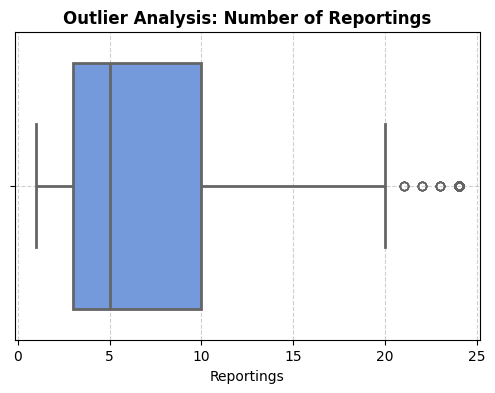

In [39]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df2['Reportings'], color='cornflowerblue', linewidth=2)
plt.title('Outlier Analysis: Number of Reportings', fontsize=12, fontweight='bold')
plt.xlabel('Reportings')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Observations
- **Most drivers have between 3 and 10 reportings. This is where most of the data lies.**
- **The middle value is 5, which means half of the drivers have 5 or fewer reportings and half have more.**
- **The normal reporting range is roughly 1 to 20.**
- **A few drivers have more than 20 reportings (around 21–24). These are unusual cases or outliers.**
- **The data is right-skewed, meaning most drivers have fewer reportings, while only a small number have very high reportings.**



**Boxplot for Age**

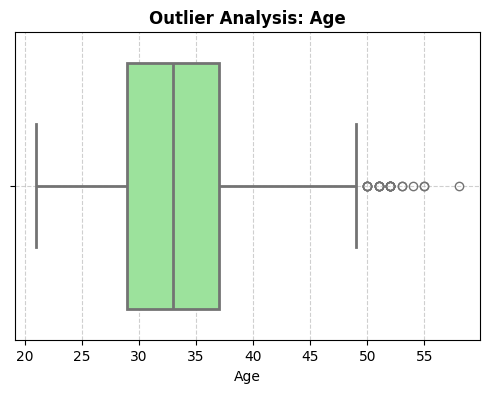

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df2['Age'], color='lightgreen', linewidth=2)
plt.title('Outlier Analysis: Age', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Observations
- **Most drivers are between 29 and 37 years old.**
- **The middle age is around 33 years, so half of the drivers are younger than 33 and half are older.**
- **The normal age range is roughly 21 to 49 years.**
- **A few drivers are above 50 years old. These are outliers.**
- **The data is slightly right-skewed, meaning most drivers are younger, with only a few older drivers.**


**Boxplot for Total Business Value**

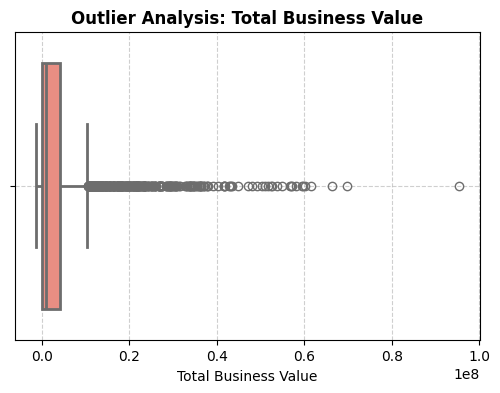

In [41]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df2['Total Business Value'], color='salmon', linewidth=2)
plt.title('Outlier Analysis: Total Business Value', fontsize=12, fontweight='bold')
plt.xlabel('Total Business Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Observations
- **Most drivers have low Total Business Value, with most of the data concentrated near zero.**
- **The data is highly right-skewed, meaning a small number of drivers generate much higher business than others.**
- **There are many outliers, with some drivers contributing extremely large business values.**
- **A small group of drivers contributes a large share of total business, while most contribute much less.**
- **Since the values vary a lot, log transformation or robust scaling would help before building machine learning models.**


**Boxplot for Income**

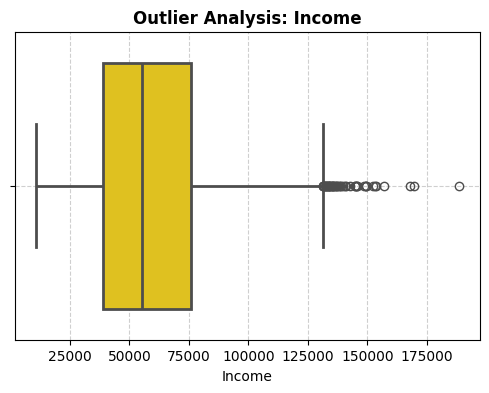

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df2['Income'], color='gold', linewidth=2)
plt.title('Outlier Analysis: Income', fontsize=12, fontweight='bold')
plt.xlabel('Income')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Observations
- **Most drivers earn between 40,000 and 75,000, where most of the income data lies.**
- **The median income is around 55,000, meaning half of the drivers earn less and half earn more.**
- **The normal income range is roughly 10,000 to 130,000.**
- **Some drivers earn more than 135,000, and a few earn up to about 190,000. These are outliers.**
- **The data is right-skewed, meaning most drivers have moderate income while a small number earn much higher income.**


---
##**Analysis and Distribution of Variables**
---
###**Statistical Summary**
---

In [43]:
df3 = df2.copy()
df3.nunique()

,0
Reportings,24
Driver_ID,2381
Age,36
Gender,2
City,29
Education_Level,3
Dateofjoining,869
LastWorkingDate,493
Grade,5
Total Business Value,1629


---
###**Data Type Conversion and Descriptive Analysis**
---

**Converting Selected Columns to Categorical Type**

In [44]:
columns_to_convert = [
    'Reportings','Gender','City','Education_Level','Grade',
    'Joining Designation','Quarterly Rating',
    'Rating_incr','Income_incr','Target'
]

df3[columns_to_convert] = df3[columns_to_convert].apply(
    lambda x: x.astype('category')
)

**Descriptive Statistics of All Variables**

In [45]:
df3.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Reportings,2381.0,24.0,5.0,309.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driver_ID,2381.0,NaN,NaN,NaN,1397.559009,1.0,695.0,1400.0,2100.0,2788.0,806.161628
Age,2381.0,NaN,NaN,NaN,33.663167,21.0,29.0,33.0,37.0,58.0,5.983375
Gender,2381.0,2.0,0.0,1404.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,2381,29,C20,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,2381.0,3.0,2.0,802.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dateofjoining,2381,NaN,NaN,NaN,2019-01-27 12:58:58.009239808,2013-01-04 00:00:00,2018-06-26 00:00:00,2019-06-23 00:00:00,2020-04-14 00:00:00,2020-12-28 00:00:00,NaN
LastWorkingDate,1616,NaN,NaN,NaN,2019-12-26 23:22:34.455445760,2018-12-31 00:00:00,2019-06-10 00:00:00,2019-12-20 12:00:00,2020-07-14 00:00:00,2020-12-28 00:00:00,NaN
Grade,2381.0,5.0,2.0,855.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Business Value,2381.0,NaN,NaN,NaN,4586741.822764,-1385530.0,0.0,817680.0,4173650.0,95331060.0,9127115.313446


---
##**Feature Classification for Exploratory Data Analysis (EDA)**
---
###**Identification of Numerical and Categorical Features**
---

In [46]:
num_cols = ['Reportings', 'Age', 'Total Business Value', 'Income']

# Considering some integer columns as categorical since they have limited unique values
cat_cols = [
    'Gender','City','Education_Level','Grade',
    'Joining Designation','Quarterly Rating',
    'Rating_incr','Income_incr','Target'
]

**Categorical Feature Distribution Analysis**

In [47]:
for col in cat_cols:
    print()
    print(f'Total Unique Values in {col} column are :- {df2[col].nunique()}')
    print(f'Value counts in {col} column are :-\n{df2[col].value_counts(normalize=True)}')
    print()
    print('-' * 120)


Total Unique Values in Gender column are :- 2
Value counts in Gender column are :-
Gender
0.0    0.589668
1.0    0.410332
Name: proportion, dtype: float64

------------------------------------------------------------------------------------------------------------------------

Total Unique Values in City column are :- 29
Value counts in City column are :-
City
C20    0.063839
C15    0.042419
C29    0.040319
C26    0.039059
C27    0.037379
C8     0.037379
C10    0.036119
C16    0.035279
C3     0.034439
C22    0.034439
C28    0.034439
C12    0.034019
C1     0.033599
C5     0.033599
C14    0.033179
C21    0.033179
C6     0.032759
C4     0.032339
C7     0.031919
C9     0.031499
C23    0.031079
C25    0.031079
C24    0.030659
C19    0.030239
C2     0.030239
C13    0.029819
C17    0.029819
C18    0.028979
C11    0.026879
Name: proportion, dtype: float64

------------------------------------------------------------------------------------------------------------------------

Total Unique Val

---
##**Univariate Analysis of Categorical Features**
---

**Gender Distribution**

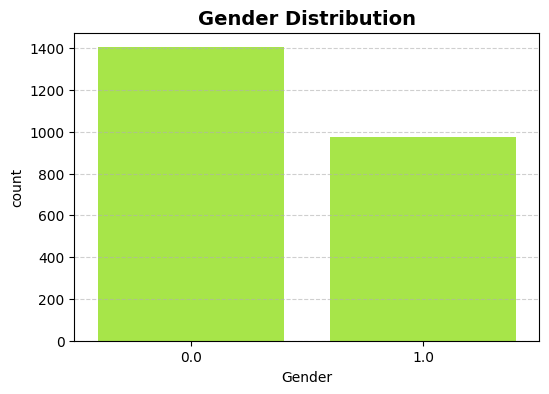

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x=df2['Gender'], color='greenyellow')
plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Observations
- **The dataset has about 2,380 drivers in total.**
- **Gender 0 has around 1,400 drivers, which is the larger group.**
- **Gender 1 has around 980 drivers, which is the smaller group.**
- **The gender distribution is slightly imbalanced, with about 59% in Gender 0 and 41% in Gender 1.**
- **The values 0 and 1 are encoded categories, which means gender has been converted into numeric form for analysis.**


**Education Level Distribution**

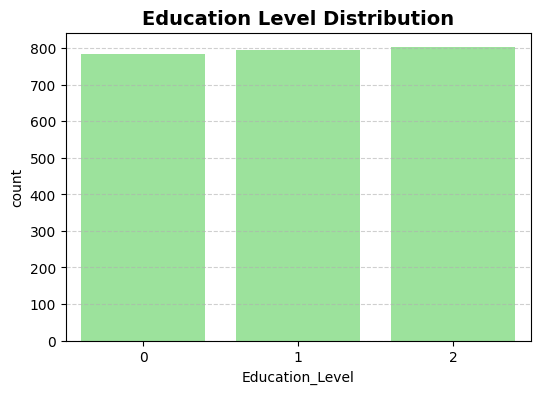

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(x=df2['Education_Level'], color='lightgreen')
plt.title('Education Level Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Observations:
- **The dataset has about 2,380 drivers.**
- **All three education levels have almost equal counts.**
- **Education Level 0 has about 785 drivers.**
- **Education Level 1 has about 795 drivers, and Education Level 2 has about 800 drivers.**
- **The education distribution is well balanced, so each category represents about one-third of the dataset.**


**Grade Distribution**

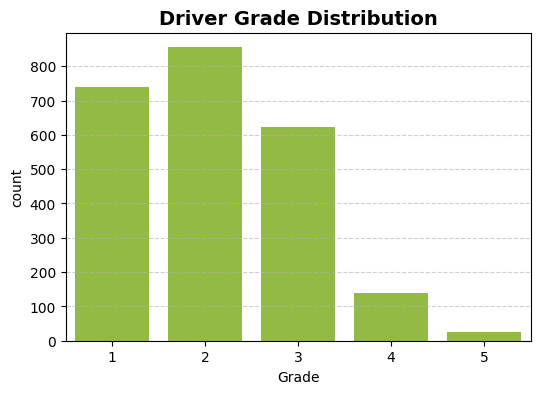

In [50]:
plt.figure(figsize=(6,4))
sns.countplot(x=df2['Grade'], color='yellowgreen')
plt.title('Driver Grade Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Observations
- Most drivers are concentrated in Grades 1, 2, and 3.
- Grade 2 is the most common, with about 860 drivers.
- Grade 1 has around 740 drivers, and Grade 3 has about 625 drivers.
- Grades 4 and 5 have much fewer drivers, with Grade 5 being very rare.
- The distribution is right-skewed, meaning most drivers belong to lower grade levels while only a few are in higher grades.

**Joining Designation Distribution**

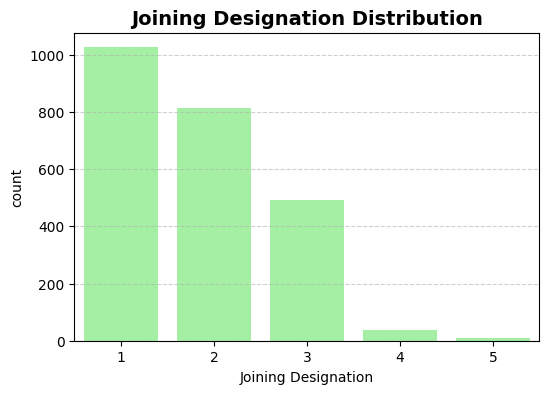

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(x=df2['Joining Designation'], color='palegreen')
plt.title('Joining Designation Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Observations
- **Most drivers join the company at lower designation levels, mainly 1 and 2.**
- **Designation 1 is the most common, with about 1,030 drivers.**
- **Designation 2 has around 815 drivers, and Designation 3 has about 490 drivers.**
- **Designations 4 and 5 have very few drivers, so higher joining levels are rare.**
- **The distribution is right-skewed, meaning most drivers join at entry-level roles while only a small number join at senior levels.**


**Quarterly Rating Distribution**

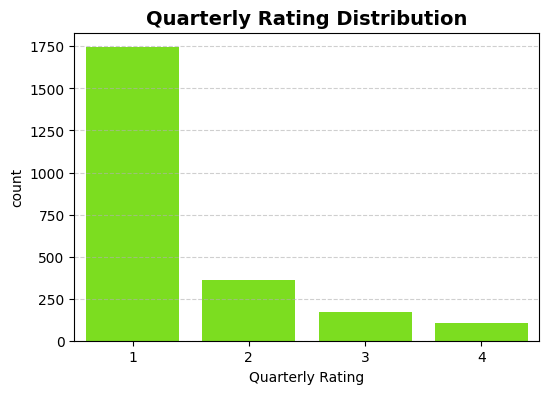

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(x=df2['Quarterly Rating'], color='lawngreen')
plt.title('Quarterly Rating Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Observations
- **Most drivers have Quarterly Rating 1, with about 1,750 drivers.**
- **Rating 2 has around 360 drivers, while Rating 3 has about 175 drivers.**
- **Rating 4 has the fewest drivers, with about 110 drivers.**
- **The distribution is highly imbalanced, with nearly 73% of drivers in Rating 1.**
- **This suggests most drivers are in lower rating levels, so Quarterly Rating may be an important factor for predicting attrition.**


**Rating Increase Indicator**

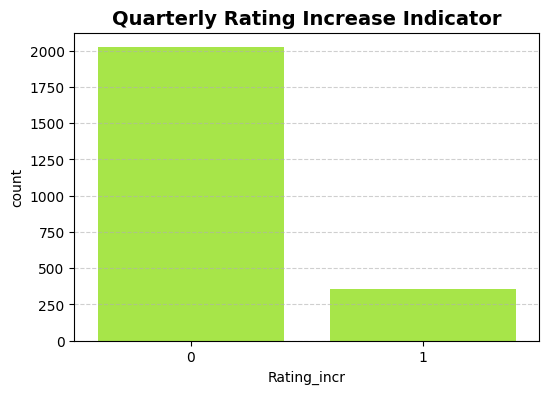

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(x=df2['Rating_incr'], color='greenyellow')
plt.title('Quarterly Rating Increase Indicator', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Observations
- **Most drivers did not get a rating increase, with about 2,025 drivers.**
- **Only about 350 drivers showed an increase in quarterly rating.**
- **Around 85% of drivers had no rating improvement, while only 15% improved.**
- **This shows a clear imbalance, where rating increase is a rare event.**
- **Since most drivers did not improve their rating, Rating_incr can be an important feature for predicting attrition.**


**Income Increase Indicator**

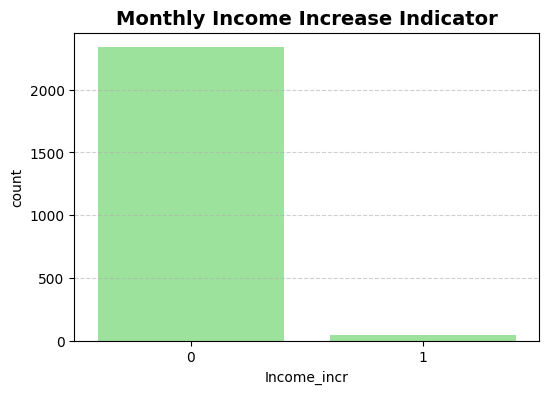

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(x=df2['Income_incr'], color='lightgreen')
plt.title('Monthly Income Increase Indicator', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Observations
- **Most drivers did not receive an income increase, with about 2,330 drivers.**
- **Only about 50 drivers received an income increase.**
- **Around 98% of drivers had no income growth, while only 2% showed an increase.**
- **This is a highly imbalanced feature, where income increase is very rare.**
- **The data suggests income growth is uncommon, so Income_incr may be an important feature for predicting driver attrition.**


**Target Variable Distribution (Driver Churn)**

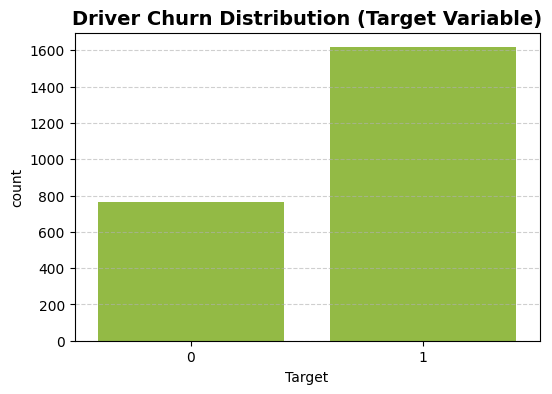

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x=df2['Target'], color='yellowgreen')
plt.title('Driver Churn Distribution (Target Variable)', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Observations:
- **The target variable shows driver churn, which means whether a driver stayed or left.**
- **About 1,615 drivers left the company, while about 765 drivers stayed.**
- **Around 68% of drivers churned, which shows a high attrition rate.**
- **The churned drivers form the majority class, while retained drivers are fewer.**
- **This high churn matches earlier patterns like low income growth and low rating improvement.**


**Univariate Analysis: City-wise Driver Distribution**

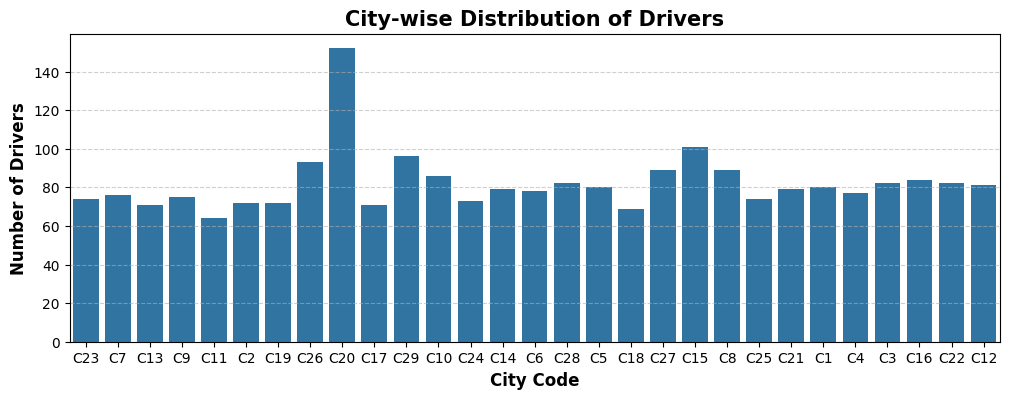

In [56]:
plt.figure(figsize=(12,4))
sns.countplot( x=df2['City'])
plt.title('City-wise Distribution of Drivers',fontsize=15,fontweight='bold')
plt.xlabel('City Code',fontsize=12,fontweight='bold')
plt.ylabel('Number of Drivers',fontsize=12,fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Observations
- **The dataset includes 29 different city codes.**
- **City C20 has the highest number of drivers, with about 152 drivers.**
- **Cities C15, C29, C26, and C8 also have relatively high driver counts.**
- **Most cities have a similar number of drivers, generally between 70 and 85.**
- **This shows the driver distribution is fairly balanced across cities, with only a few cities having noticeably higher concentration**


**Churn Analysis by Last Working Month**

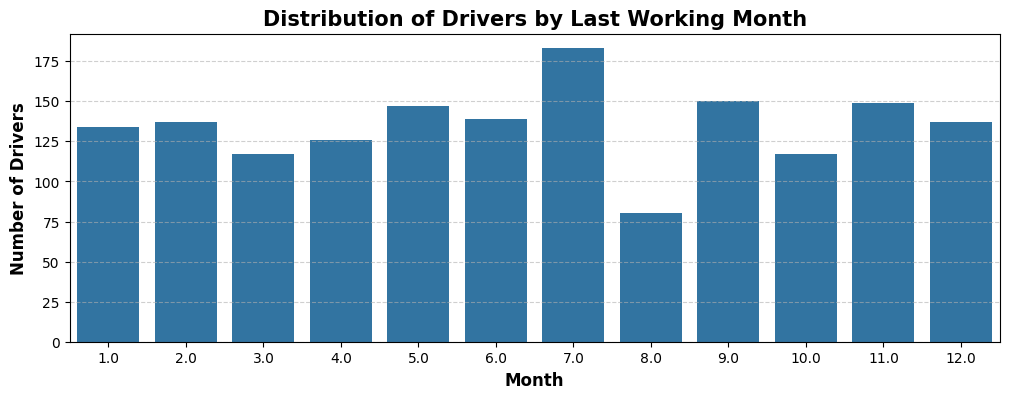

In [57]:
plt.figure(figsize=(12,4))
sns.countplot(x=df2['LastWorkingDate'].dt.month)
plt.title('Distribution of Drivers by Last Working Month',fontsize=15,fontweight='bold')
plt.xlabel('Month',fontsize=12,fontweight='bold')
plt.ylabel('Number of Drivers',fontsize=12,fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Observations
- Driver exits happen throughout the year, with monthly churn staying fairly active.
- July has the highest number of driver exits, with about 185 drivers leaving.
- August has the lowest churn, with about 80 drivers leaving.
- In most other months, driver exits are fairly steady, usually between 115 and 150.
- This suggests possible seasonal churn patterns, where some months see higher attrition than others.



**Churn Analysis by Last Working Year**

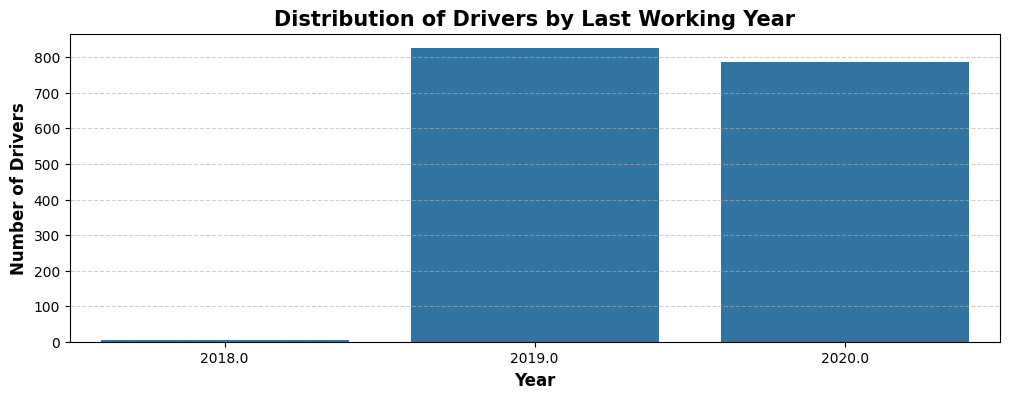

In [58]:
plt.figure(figsize=(12,4))
sns.countplot(x=df2['LastWorkingDate'].dt.year)
plt.title('Distribution of Drivers by Last Working Year',fontsize=15,fontweight='bold')
plt.xlabel('Year',fontsize=12,fontweight='bold')
plt.ylabel('Number of Drivers',fontsize=12,fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Observations
- Very few drivers left in 2018, with only about 10 exits.
- Most driver churn happened in 2019 and 2020.
- 2019 had the highest churn, with about 825 drivers leaving.
- 2020 also had high churn, with around 790 drivers leaving.
- This shows that almost all attrition happened during 2019–2020, indicating a period of high driver turnover.

**Distribution of Month of Joining**

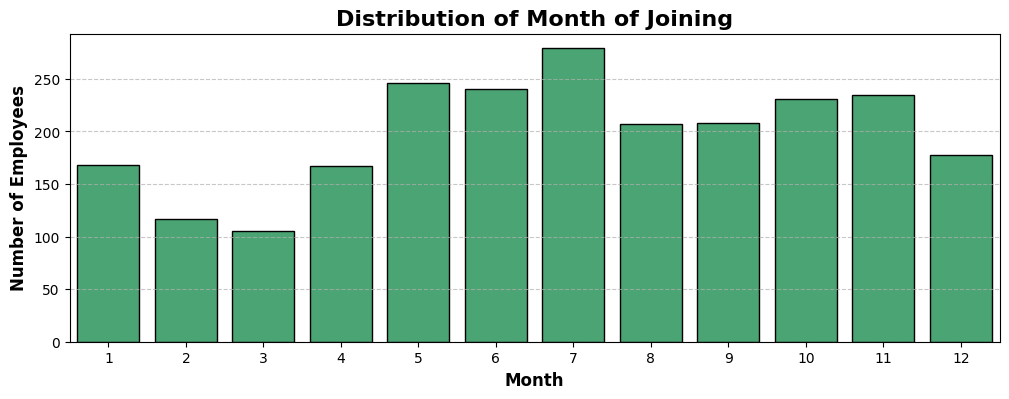

In [59]:
plt.figure(figsize=(12,4))
sns.countplot(x=df2['Dateofjoining'].dt.month, color='mediumseagreen',  edgecolor='black')
plt.title('Distribution of Month of Joining', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Number of Employees', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Observations
- Driver joining happens throughout the year, so hiring is spread across all months.
- July has the highest number of new drivers joining, with about 280 drivers.
- March has the lowest number of joinings, with a little over 100 drivers.
- May, June, October, and November also show relatively high joining activity.
- This suggests mid-year and later months have stronger hiring activity compared to the beginning of the year.

**Distribution of Year of Joining**

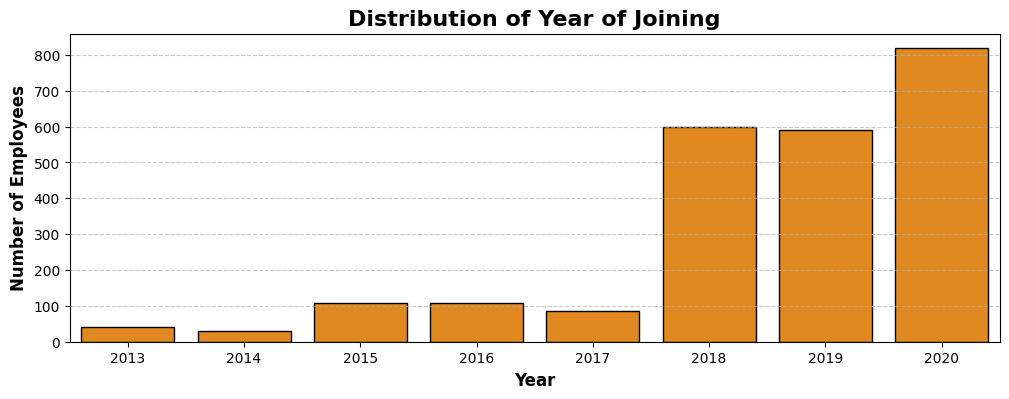

In [60]:
plt.figure(figsize=(12,4))
sns.countplot(x=df2['Dateofjoining'].dt.year, color='darkorange',edgecolor='black')
plt.title('Distribution of Year of Joining', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Employees', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Observations
- **Hiring was low and fairly stable from 2013 to 2017.**
- **Recruitment increased sharply from 2018, showing rapid business expansion.**
- **2020 had the highest number of new drivers joining.**
- **Earlier analysis showed that most driver exits also happened in 2019 and 2020.**
- **This suggests a high hiring–high churn period, where many drivers joined but many also left within a short time.**


**Calculating Total Business Value for Each Grade**

In [61]:
grade_wise_value = df2.groupby('Grade')['Total Business Value'].sum()

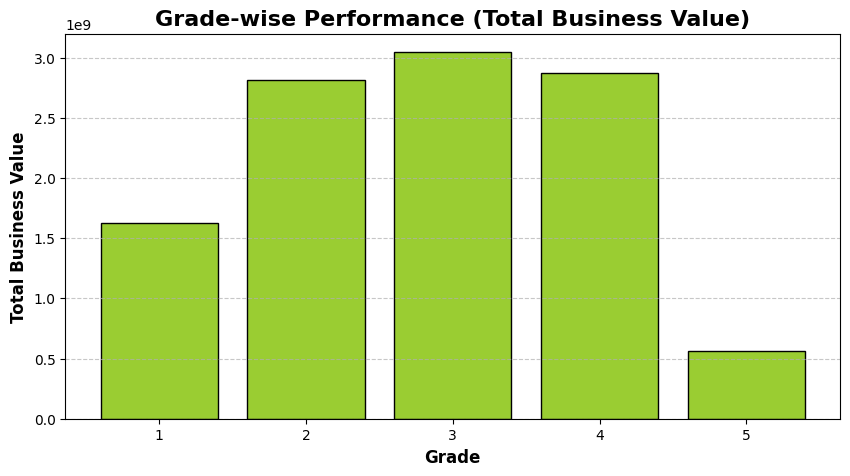

In [62]:
plt.figure(figsize=(10,5))
plt.bar(grade_wise_value.index, grade_wise_value.values,
    color='yellowgreen', edgecolor='black')
plt.xlabel('Grade', fontsize=12, fontweight='bold')
plt.ylabel('Total Business Value', fontsize=12, fontweight='bold')
plt.title('Grade-wise Performance (Total Business Value)', fontsize=16, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Observations
- Grades 3 and 4 generate the highest business value among all driver grades.
- Grade 3 is the top contributor, even though it has fewer drivers than Grade 2.
- Grade 2 has the largest number of drivers, but its total business value is slightly lower than Grade 3.
- Grade 4 has fewer drivers but very high business value, showing strong productivity.
- This suggests mid-to-higher grade drivers contribute more business value per driver than lower grade drivers.

---
###**Creating a Copy of the Dataset for Safe Analysis**
---

In [63]:
df4=df1.copy()

**Convert reporting date to datetime Format**

In [64]:
df4['Reporting_Date'] = pd.to_datetime(df4['Reporting_Date'])

**Identifying the Date Range for the past year**

In [65]:
last_date = df4['Reporting_Date'].max()
one_year_ago = last_date - pd.DateOffset(years=1)

**Filter data for the past year**

In [66]:
df_past_year = df4[df4['Reporting_Date'] >= one_year_ago]

**Check if filtered data is empty**

In [67]:
if df_past_year.empty:
    raise ValueError("No data available for the past year. Please check the date range or the data.")

**Aggregating Start and End Quarterly Ratings by City**

In [68]:
rating_change = df_past_year.groupby('City').agg(
    start_rating=('Quarterly Rating', 'first'),
    end_rating=('Quarterly Rating', 'last')
).reset_index()

**Calculating Quarterly Rating Improvement for Each City**

In [69]:

rating_change['rating_improvement'] = rating_change['end_rating'] - rating_change['start_rating']

In [70]:
# Validating Availability of Improvements
if rating_change.empty or rating_change['rating_improvement'].isnull().all():
    raise ValueError("No improvements found. Please check the data.")

# Identifying the City with the Highest Rating Improvement
most_improved_city = rating_change.loc[rating_change['rating_improvement'].idxmax(), 'City']
print(f'The city with the most improvement in Quarterly Rating over the past year is: {most_improved_city}')

The city with the most improvement in Quarterly Rating over the past year is: C22


---
###**Calculating Total Business Value for Each City**
---

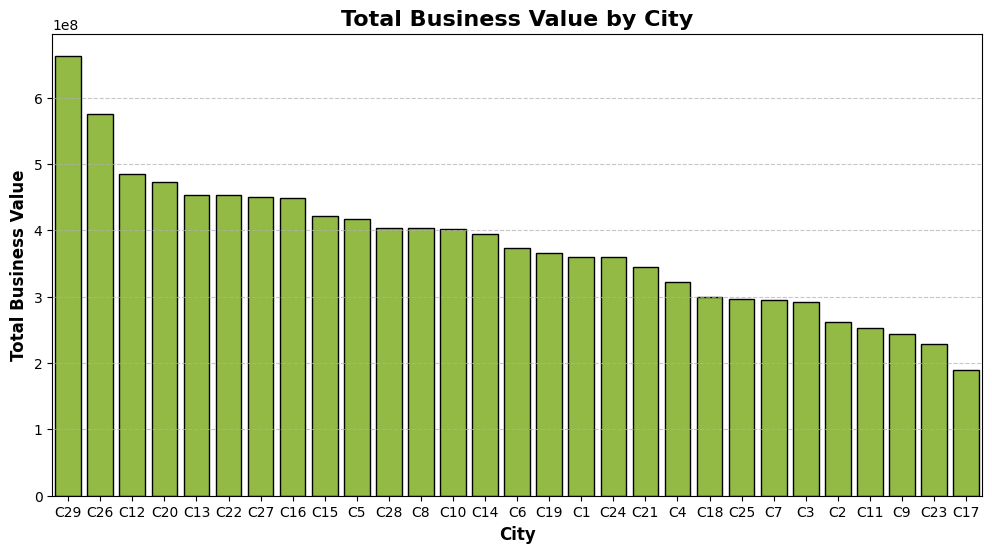

In [71]:
# Aggregate total business value by city
city_tbv = df4.groupby('City')['Total Business Value'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(
    data=city_tbv.sort_values('Total Business Value', ascending=False),
    x='City',
    y='Total Business Value',
    color='yellowgreen',
    edgecolor='black'
)

plt.title('Total Business Value by City', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12, fontweight='bold')
plt.ylabel('Total Business Value', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Observations
- **City C29 generates the highest total business value, even though it does not have the most drivers.**
- **Cities C26, C12, and C20 are also strong revenue contributors.**
- **City C20 has the largest number of drivers, but it is not the highest revenue city.**
- **City C17 has the lowest total business value among all cities.**
- **This shows that more drivers do not always mean higher revenue — some cities are more efficient than others.**


---
###**Extract Month and Quarter from Reporting Date**
---

In [72]:
df4['Month'] = df4['Reporting_Date'].dt.month
df4['Quarter'] = df4['Reporting_Date'].dt.quarter

**Aggregate Quarterly Ratings by Month and Quarter**

In [73]:
# Aggregate Quarterly Ratings
ratings_by_month = df4.groupby('Month')['Quarterly Rating'].mean()
ratings_by_quarter = df4.groupby('Quarter')['Quarterly Rating'].mean()

**Plot Average Quarterly Rating by Month and Quarter**

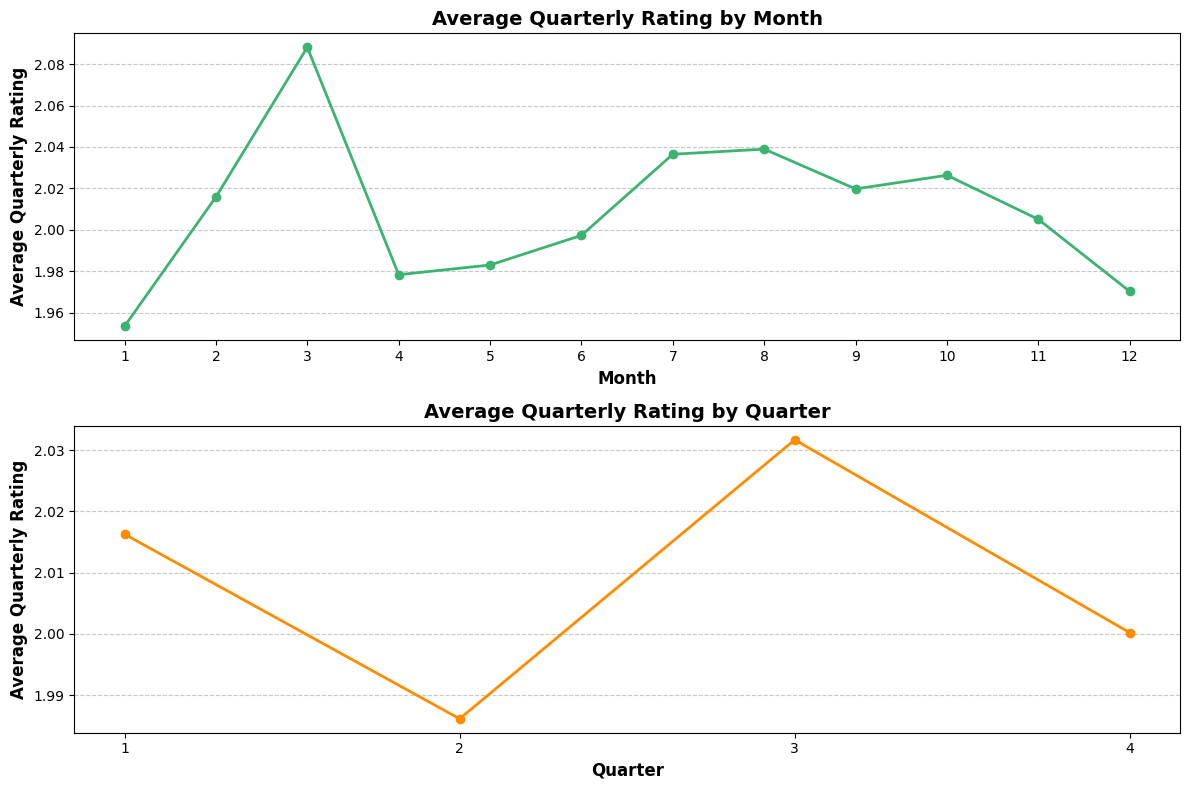

In [74]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(ratings_by_month.index, ratings_by_month.values, marker='o', color='mediumseagreen', linewidth=2)
plt.title('Average Quarterly Rating by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Average Quarterly Rating', fontsize=12, fontweight='bold')
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 1, 2)
plt.plot(ratings_by_quarter.index, ratings_by_quarter.values, marker='o', color='darkorange', linewidth=2)
plt.title('Average Quarterly Rating by Quarter', fontsize=14, fontweight='bold')
plt.xlabel('Quarter', fontsize=12, fontweight='bold')
plt.ylabel('Average Quarterly Rating', fontsize=12, fontweight='bold')
plt.xticks(range(1, 5))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#Observations
- **Average quarterly rating changes slightly across the year, but stays within a narrow range.**
- **March shows the highest average rating, making it the strongest month for performance.**
- **After March, ratings drop in April and then gradually improve again through the middle of the year.**
- **Quarter 3 has the best overall average performance among all quarters.**
- **Ratings decline toward the end of the year, which may indicate lower engagement or seasonal fatigue.**


---
###**Gender vs Churn**
---

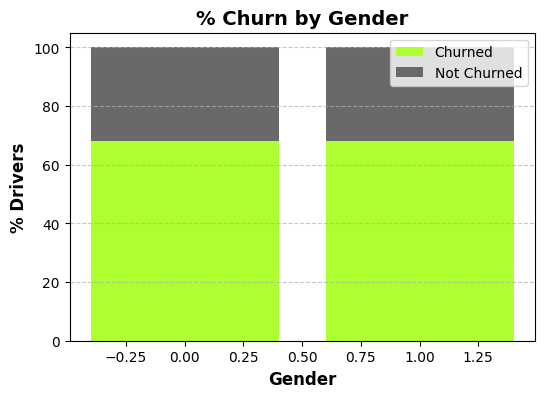

In [75]:
# Aggregate by Gender
data_gender = df2.pivot_table(index='Gender', columns='Target', aggfunc='size')
data_gender = data_gender.div(data_gender.sum(axis=1), axis=0).multiply(100).round()
data_gender.reset_index(inplace=True)

plt.figure(figsize=(6,4))
plt.bar(data_gender['Gender'], data_gender[1], color='greenyellow', label='Churned')
plt.bar(data_gender['Gender'], data_gender[0], color='dimgrey', bottom=data_gender[1], label='Not Churned')
plt.xlabel('Gender', fontsize=12, fontweight='bold')
plt.ylabel('% Drivers', fontsize=12, fontweight='bold')
plt.title('% Churn by Gender', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Observations
- **Both gender groups have almost the same churn rate, around 68%.**
- **Even though the number of drivers differs by gender, attrition is similar in both groups.**
- **This suggests gender does not strongly affect whether a driver leaves or stays.**
- **The churn pattern is close to the overall dataset churn rate.**
- **Other factors like income growth, rating improvement, and business value are likely more important for predicting churn.**


---
###**Education Level vs Churn**
---

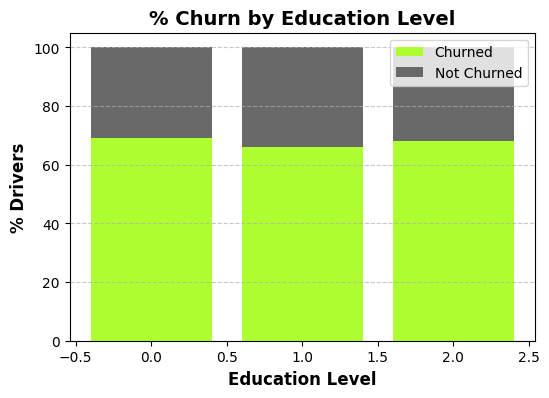

In [76]:
data_edu = df2.pivot_table(index='Education_Level', columns='Target', aggfunc='size')
data_edu = data_edu.div(data_edu.sum(axis=1), axis=0).multiply(100).round()
data_edu.reset_index(inplace=True)

plt.figure(figsize=(6,4))
plt.bar(data_edu['Education_Level'], data_edu[1], color='greenyellow', label='Churned')
plt.bar(data_edu['Education_Level'], data_edu[0], color='dimgrey', bottom=data_edu[1], label='Not Churned')
plt.xlabel('Education Level', fontsize=12, fontweight='bold')
plt.ylabel('% Drivers', fontsize=12, fontweight='bold')
plt.title('% Churn by Education Level', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Observations
- **Gender is slightly imbalanced, but education levels are well balanced across the dataset.**
- **Churn is almost the same across education levels, so education does not seem to strongly affect attrition.**
- **Most drivers are concentrated in lower joining designations, lower grades, and lower quarterly ratings.**
- **City C20 has the most drivers, but City C29 generates the highest business value.**
- **This suggests retaining drivers in high-revenue cities like C29 should be important for the business.**


---
###**Grade vs Churn**
---

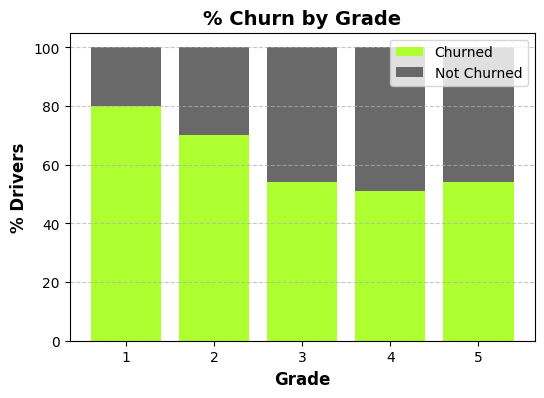

In [77]:
data_grade = df2.pivot_table(index='Grade', columns='Target', aggfunc='size')
data_grade = data_grade.div(data_grade.sum(axis=1), axis=0).multiply(100).round()
data_grade.reset_index(inplace=True)

plt.figure(figsize=(6,4))
plt.bar(data_grade['Grade'], data_grade[1], color='greenyellow', label='Churned')
plt.bar(data_grade['Grade'], data_grade[0], color='dimgrey', bottom=data_grade[1], label='Not Churned')
plt.xlabel('Grade', fontsize=12, fontweight='bold')
plt.ylabel('% Drivers', fontsize=12, fontweight='bold')
plt.title('% Churn by Grade', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#Observations
- **The dataset shows high churn (about 68%), and this is similar across gender and education levels.**
- **Most drivers joined during 2018–2020 and are concentrated in lower joining designations, lower grades, and lower ratings.**
- **Income growth and rating improvement are rare, which suggests limited progression for most drivers.**
- **Grade 3 and 4 drivers generate the highest business value, even though they are fewer in number.**
- **City C20 has the most drivers, but City C29 generates the highest revenue, showing that driver count and business value do not always move together.**


---
###**Joining Designation vs Churn**
---

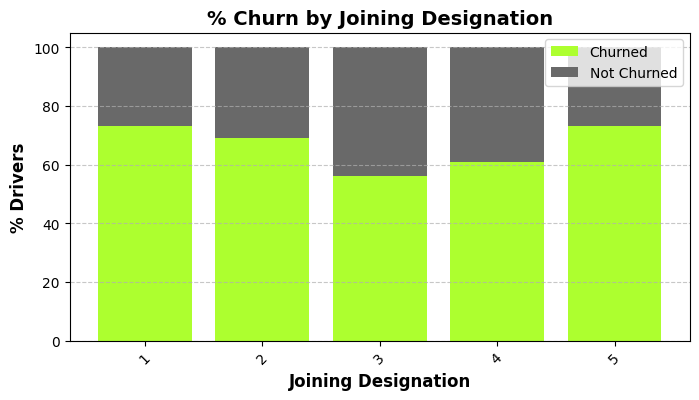

In [78]:
data_designation = df2.pivot_table(index='Joining Designation', columns='Target', aggfunc='size')
data_designation = data_designation.div(data_designation.sum(axis=1), axis=0).multiply(100).round()
data_designation.reset_index(inplace=True)

plt.figure(figsize=(8,4))
plt.bar(data_designation['Joining Designation'], data_designation[1], color='greenyellow', label='Churned')
plt.bar(data_designation['Joining Designation'], data_designation[0], color='dimgrey', bottom=data_designation[1], label='Not Churned')
plt.xlabel('Joining Designation', fontsize=12, fontweight='bold')
plt.ylabel('% Drivers', fontsize=12, fontweight='bold')
plt.title('% Churn by Joining Designation', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Observations
- **The workforce is concentrated in lower joining designations, lower grades, and lower quarterly ratings.**
- **Income growth and rating improvement are rare, showing limited career progression for most drivers.**
- **Grade 3 and 4 drivers are the most productive, generating high business value despite having fewer drivers.**
- **Overall churn is high, and it is highest among Grade 1 and lower designation drivers.**
- **City C20 has the most drivers, but City C29 is the most profitable, showing that business efficiency differs across cities.**


---
###**Quarterly Rating vs Churn**
---

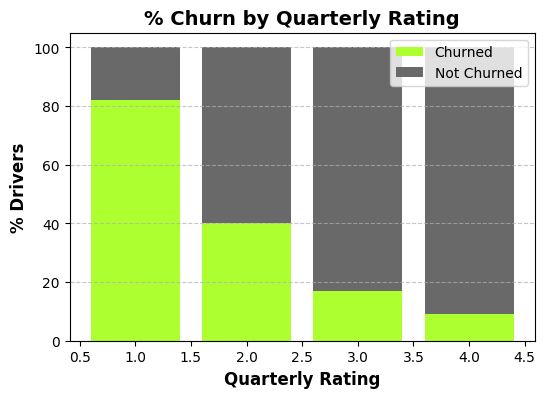

In [79]:
data_qrating = df2.pivot_table(index='Quarterly Rating', columns='Target', aggfunc='size')
data_qrating = data_qrating.div(data_qrating.sum(axis=1), axis=0).multiply(100).round()
data_qrating.reset_index(inplace=True)

plt.figure(figsize=(6,4))
plt.bar(data_qrating['Quarterly Rating'], data_qrating[1], color='greenyellow', label='Churned')
plt.bar(data_qrating['Quarterly Rating'], data_qrating[0], color='dimgrey', bottom=data_qrating[1], label='Not Churned')
plt.xlabel('Quarterly Rating', fontsize=12, fontweight='bold')
plt.ylabel('% Drivers', fontsize=12, fontweight='bold')
plt.title('% Churn by Quarterly Rating', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#Observations:
- **Quarterly rating is strongly linked to churn — as ratings improve, churn decreases.**
- **Drivers with Rating 1 have the highest churn, at around 80%.**
- **Drivers with Rating 2 have lower churn, around 65%.**
- **Drivers with Ratings 3 and 4 have much better retention, with churn around 45%.**
- **This suggests a stagnation pattern — drivers with low ratings, low growth, and limited progression are more likely to leave.**



---
###**Rating Increase vs Churn**
---

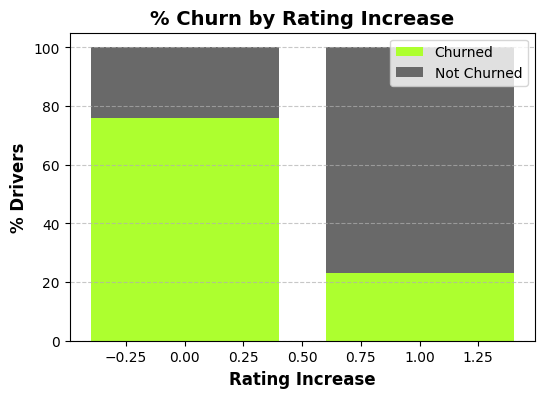

In [80]:
data_rating_incr = df2.pivot_table(index='Rating_incr', columns='Target', aggfunc='size')
data_rating_incr = data_rating_incr.div(data_rating_incr.sum(axis=1), axis=0).multiply(100).round()
data_rating_incr.reset_index(inplace=True)

plt.figure(figsize=(6,4))
plt.bar(data_rating_incr['Rating_incr'], data_rating_incr[1], color='greenyellow', label='Churned')
plt.bar(data_rating_incr['Rating_incr'], data_rating_incr[0], color='dimgrey', bottom=data_rating_incr[1], label='Not Churned')
plt.xlabel('Rating Increase', fontsize=12, fontweight='bold')
plt.ylabel('% Drivers', fontsize=12, fontweight='bold')
plt.title('% Churn by Rating Increase', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#Observations
- **Drivers without a rating increase have very high churn, around 78%.**
- **Drivers who received a rating increase have much lower churn, around 22%.**
- **This shows that rating improvement strongly improves retention.**
- **Drivers with career growth are much more likely to stay than drivers with no progress.**
- **Rating increase appears to be one of the strongest predictors of driver attrition**


---
###**Income Increase vs Churn**
---

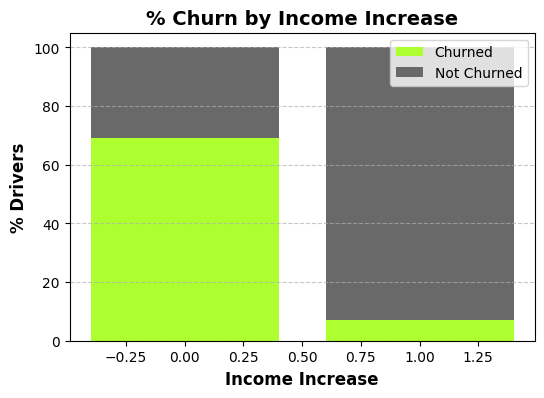

In [81]:
data_income_incr = df2.pivot_table(index='Income_incr', columns='Target', aggfunc='size')
data_income_incr = data_income_incr.div(data_income_incr.sum(axis=1), axis=0).multiply(100).round()
data_income_incr.reset_index(inplace=True)

plt.figure(figsize=(6,4))
plt.bar(data_income_incr['Income_incr'], data_income_incr[1], color='greenyellow', label='Churned')
plt.bar(data_income_incr['Income_incr'], data_income_incr[0], color='dimgrey', bottom=data_income_incr[1], label='Not Churned')
plt.xlabel('Income Increase', fontsize=12, fontweight='bold')
plt.ylabel('% Drivers', fontsize=12, fontweight='bold')
plt.title('% Churn by Income Increase', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Observations
- **Most drivers did not receive income growth or rating improvement, showing limited career progression.**
- **Drivers without income increase have high churn, while drivers who received income growth are much more likely to stay.**
- **Drivers without rating improvement have very high churn, but drivers with rating growth have much better retention.**
- **This suggests career stagnation is a major reason behind the high churn rate**
- **Improving income growth, rating progression, and support for low-rated drivers can help reduce attrition.**


---
###**City-wise Churn Analysis**
---

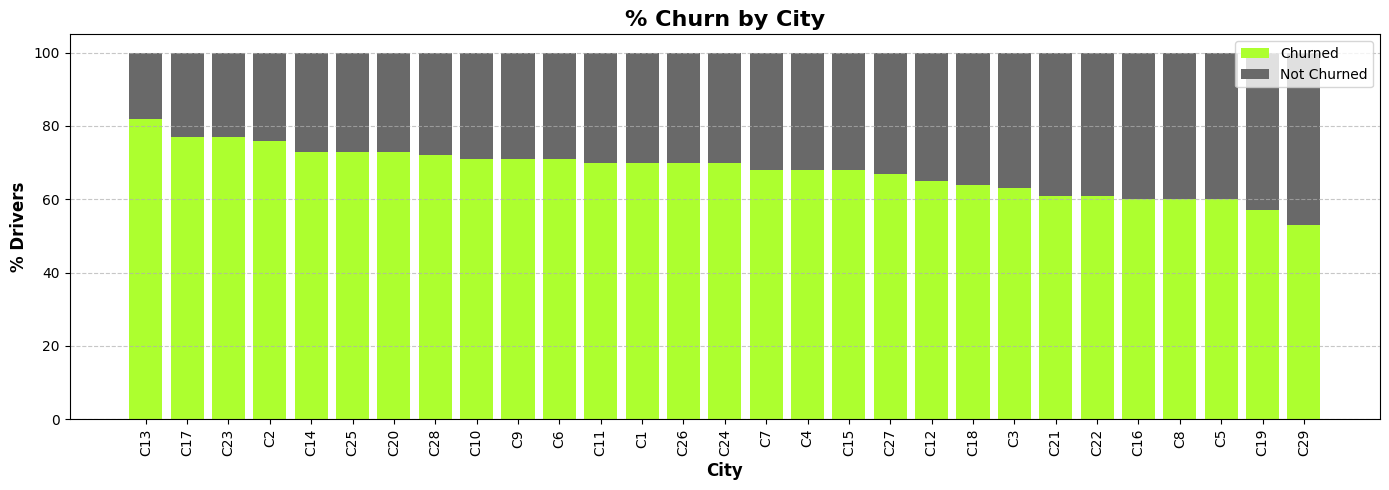

In [82]:
city = df2.pivot_table(index='City', columns='Target', aggfunc='size')
city = city.div(city.sum(axis=1), axis=0).multiply(100).round()
city.reset_index(inplace=True)
city = city.sort_values(by=1, ascending=False)  # Sort by % churned descending

# Plot
plt.figure(figsize=(14,5))
plt.bar(city['City'], city[1], color='greenyellow', label='Churned')
plt.bar(city['City'], city[0], color='dimgrey', bottom=city[1], label='Not Churned')

plt.xlabel('City', fontsize=12, fontweight='bold')
plt.ylabel('% Drivers', fontsize=12, fontweight='bold')
plt.title('% Churn by City', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

#Observations
- **The company has high driver churn, with many more drivers leaving than staying.**
- **Most churn happened during 2019–2020, which was also the period of rapid hiring.**
- **Lack of growth is the biggest churn driver — drivers with low ratings, no rating improvement, and no income increase are more likely to leave.**
- **Entry-level drivers have the highest attrition, while higher-grade drivers show better retention and stronger business contribution.**
- **City C29 is more profitable than C20, showing that driver count alone does not determine business value.**


---
###**Churn Analysis by Joining Month**
---

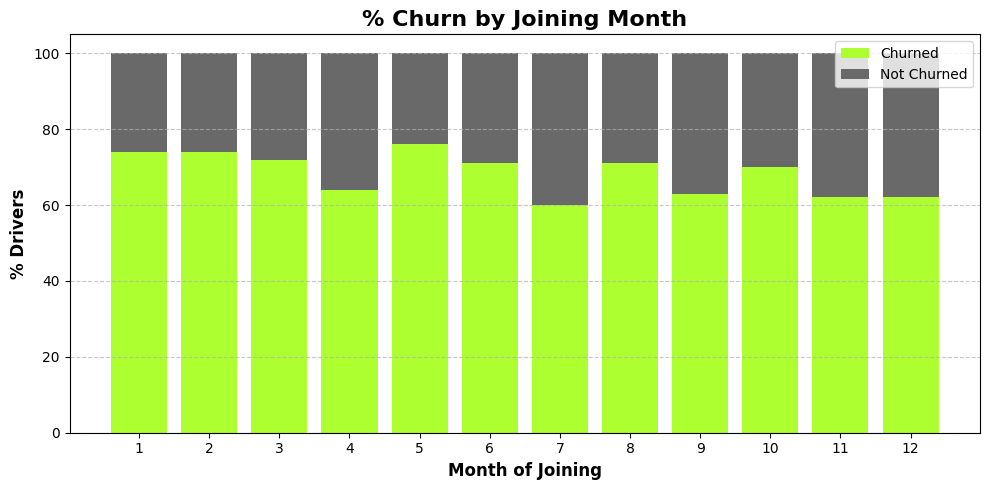

In [83]:
m = df2.pivot_table(index=df2['Dateofjoining'].dt.month, columns='Target', aggfunc='size')
m = m.div(m.sum(axis=1), axis=0).multiply(100).round()
m.reset_index(inplace=True)

# Plot
plt.figure(figsize=(10,5))
plt.bar(m['Dateofjoining'], m[1], color='greenyellow', label='Churned')
plt.bar(m['Dateofjoining'], m[0], color='dimgrey', bottom=m[1], label='Not Churned')

# Labels, title, and formatting
plt.xlabel('Month of Joining', fontsize=12, fontweight='bold')
plt.ylabel('% Drivers', fontsize=12, fontweight='bold')
plt.title('% Churn by Joining Month', fontsize=16, fontweight='bold')
plt.xticks(range(1,13))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

#Observations
- **Quarterly rating is strongly linked to churn and acts as an important retention signal**
- **Drivers with Rating 1 have the highest churn, around 80%.**
- **Drivers with Rating 2 also have high churn, around 65%.**
- **Churn drops sharply once drivers reach Rating 3 or 4, where churn is around 45%.**
- **This suggests that moving drivers from low ratings to Rating 3 or above can significantly improve retention.**


---
###**Churn Analysis by Joining Year**
---

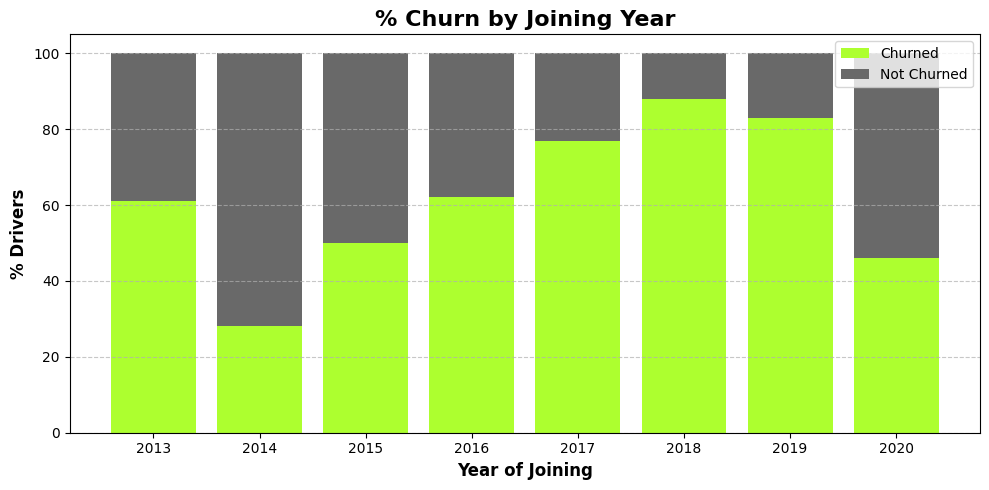

In [84]:
y = df2.pivot_table(index=df2['Dateofjoining'].dt.year, columns='Target', aggfunc='size')
y = y.div(y.sum(axis=1), axis=0).multiply(100).round()
y.reset_index(inplace=True)

# Plot
plt.figure(figsize=(10,5))
plt.bar(y['Dateofjoining'], y[1], color='greenyellow', label='Churned')
plt.bar(y['Dateofjoining'], y[0], color='dimgrey', bottom=y[1], label='Not Churned')

# Labels, title, and formatting
plt.xlabel('Year of Joining', fontsize=12, fontweight='bold')
plt.ylabel('% Drivers', fontsize=12, fontweight='bold')
plt.title('% Churn by Joining Year', fontsize=16, fontweight='bold')
plt.xticks(y['Dateofjoining'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

#Observations
- **The company hired many drivers during 2018–2020, and most churn also happened during the same period.**
- **July shows higher driver exits, suggesting possible seasonal attrition.**
- **Low ratings, no rating improvement, and no income growth are strongly linked to higher churn.**
- **Drivers with rating growth or income increases are much more likely to stay.**
- **City C29 and Grade 3 drivers generate high business value, so retaining these drivers should be a business priority.**


---
###**Numerical Column Analysis**
---

In [85]:
for _ in num_cols:
    print()
    print(f'Total Unique Values in {_} column are :- {df2[_].nunique()}')
    print(f'Value counts in {_} column are :-\n {df2[_].value_counts(normalize=True)}')
    print()
    print('-'*120)


Total Unique Values in Reportings column are :- 24
Value counts in Reportings column are :-
 Reportings
5     0.129777
3     0.110458
4     0.102898
24    0.096178
2     0.085258
6     0.082738
1     0.076018
7     0.057119
9     0.045779
8     0.043259
10    0.023520
11    0.023100
13    0.021000
14    0.020580
12    0.018060
18    0.013020
15    0.010500
17    0.010080
19    0.008400
16    0.007560
20    0.006300
23    0.003360
22    0.002520
21    0.002520
Name: proportion, dtype: float64

------------------------------------------------------------------------------------------------------------------------

Total Unique Values in Age column are :- 36
Value counts in Age column are :-
 Age
32.0    0.072239
31.0    0.071819
34.0    0.069299
30.0    0.064259
33.0    0.060479
36.0    0.057539
35.0    0.057539
29.0    0.054599
37.0    0.051239
28.0    0.050399
27.0    0.046619
38.0    0.039479
39.0    0.035699
25.0    0.032759
26.0    0.031919
41.0    0.031499
40.0    0.026459
42.0   

---
###**Numerical Feature Distribution by Target**
---

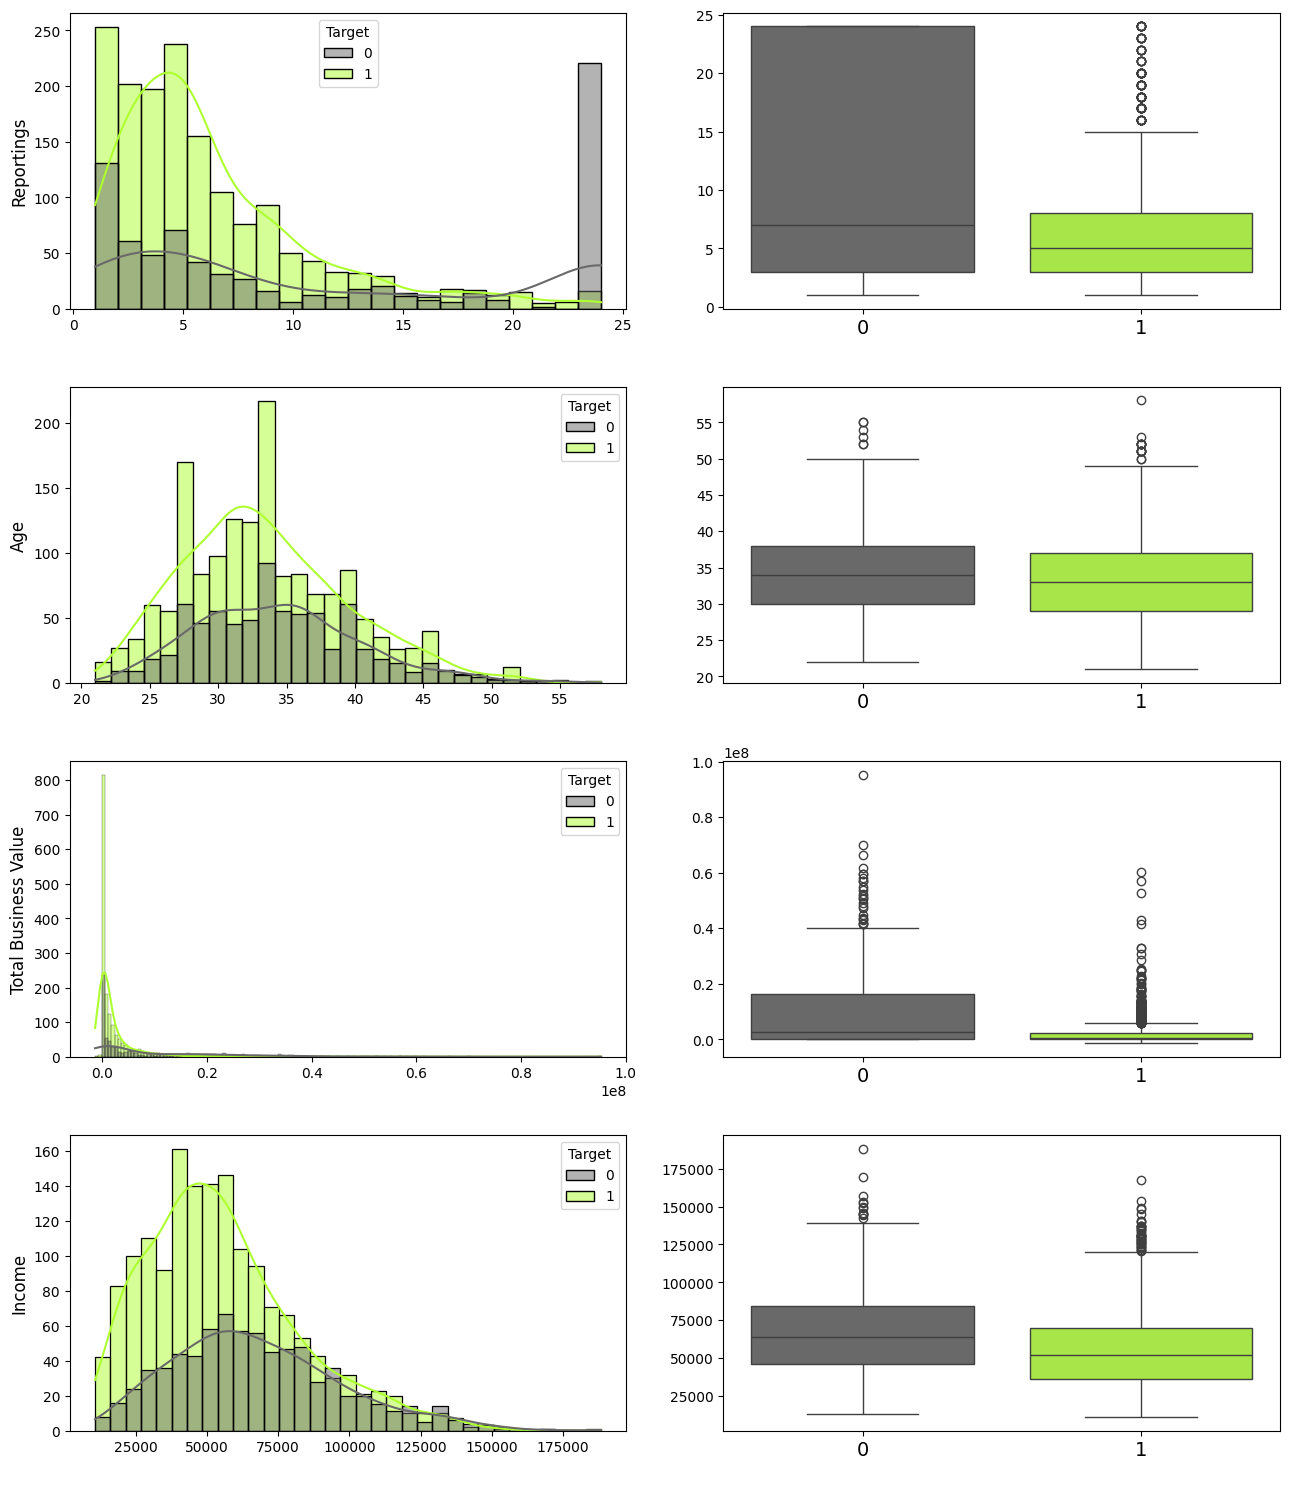

In [86]:
import warnings
import matplotlib.colors as mcolors
import seaborn as sns

warnings.simplefilter(action='ignore', category=FutureWarning)
fig, ax = plt.subplots(4,2,figsize=(13,15))
i=0
color_dict = {0: 'dimgrey', 1: 'greenyellow'}
for col in num_cols:
    sns.boxplot(data=df2, y=col, x='Target', ax=ax[i,1],
               palette=('dimgrey','greenyellow'))
    sns.histplot(data=df2, x=col, hue='Target', ax=ax[i, 0], legend=True,
                palette=color_dict, kde=True, fill=True)
    ax[i,0].set_ylabel(col, fontsize=12)
    ax[i,0].set_xlabel(' ')
    ax[i,1].set_xlabel(' ')
    ax[i,1].set_ylabel(' ')
    ax[i,1].xaxis.set_tick_params(labelsize=14)
    i += 1

plt.tight_layout()
plt.show()

#Observations
- **The company hired many drivers during 2018–2020, and most driver exits also happened during this period.**
- **July shows higher churn, suggesting some seasonal pattern in driver departures.**
- **Low ratings, no rating improvement, and no income growth are strongly linked to higher attrition.**
- **Drivers who receive rating increases or income growth are much more likely to stay.**
- **Grade 3 drivers and City C29 generate high business value, so retaining these drivers should be a business priority.**


---
##**Relationship Among Features: Correlation, Regression, and Hypothesis Testing**
---
>**Before modeling, it’s important to understand how features relate to each other.**
- **This includes:**
  - **Correlation analysis – checks linear relationships among numeric features.**
  - **OLS Regression Analysis – quantifies relationships between independent and dependent variables.**
  - **Hypothesis Testing – checks if observed differences or relationships are statistically significant.**
---


---
###**Correlation Analysis**
---

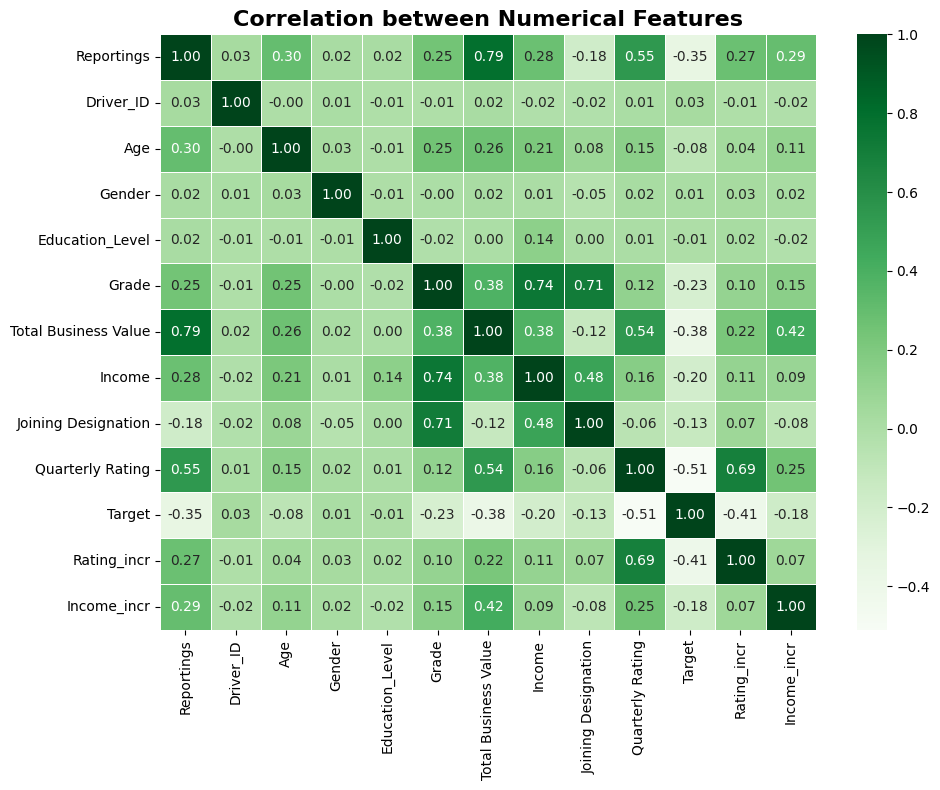

In [87]:
# Select numerical features
numerical_df2 = df2.select_dtypes(include=['int64', 'float64'])

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    numerical_df2.corr(),
    annot=True,
    fmt=".2f",
    cmap='Greens',
    cbar=True,
    linewidths=0.5
)
plt.title('Correlation between Numerical Features', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#Observations:
- **Rapid hiring happened during 2018–2020, and most driver churn also happened during the same period.**
- **Low career growth is the main reason for churn — drivers with low ratings, no rating increase, and no income growth are much more likely to leave.**
- **Drivers with Rating 1 are the highest-risk group, with about 80% churn, while churn drops sharply for drivers with Rating 3 or 4.**
- **Grade 3 drivers and City C29 generate strong business value, showing that a smaller but efficient group contributes heavily to revenue.**
- **To reduce churn, Ola should focus on rating improvement, income progression, and retention support for new and low-performing drivers.**


---
###**WHAT IS THE BUSINESS QUESTION**
---
>**If a Driver's Quarterly rating drops sharply, does next month's Business value also change?**
- **This is not Churn Prediction**
- **It is Impact analysis**
---

**1.IMPORT LIBRARIES**

In [88]:
import statsmodels.api as sm
import pandas as pd

**2. DEFINE WHAT SIGNIFICANT DROP MEANS**


In [89]:
significant_drop_threshold = 2

>**This Means:**
- **If Rating falls by 2 or more points, mark it as a major drop**

**3.CALCULATE RATING CHANGE FOR EACH DRIVER**

In [90]:
df4['Rating_Drop'] = df4.groupby('Driver_ID')['Quarterly Rating'].diff()

- **It calculates change within each driver separately**
- **Current month rating - Previous month rating**
- **Negative : Rating Dropped**
- **Positive : Rating improved**

**4. MARK SIGNIFICANT DROPS**

In [91]:
df4['Significant_Drop'] = df4['Rating_Drop'] <= -significant_drop_threshold

>**If Threshold = 2:**
- **-2, -3, -4 : True**
- **-1, 0, 1 : False**


**5. TAKE NEXT MONTH BUSINESS VALUE**

In [92]:
df4['Subsequent_Business_Value'] = df4.groupby('Driver_ID')['Total Business Value'].shift(-1)

- **What shift(-1) means**
  - **Take next row’s value within each driver.**
- **so now:**
  - **after rating falls in current month, what happens next month?**


**6. KEEP ONLY SIGNIFICANT DROPS**

In [93]:
significant_drops = df4[df4['Significant_Drop']]

- **Now only rows where rating fell sharply remain.**

**7.PREPARE REGRESSION DATASET**

In [94]:
regression_data = significant_drops[['Rating_Drop', 'Subsequent_Business_Value']].dropna()

>**Keep only:**
- **Predictor : rating_drop**
- **Outcome : subsequent_Business_Value**
- **Remove Missing values**

**8.ADD INTERCEPT**

In [95]:
regression_data = sm.add_constant(regression_data)

>**OLS Needs:**
- **y = Beta0 + Beta1(x)**
- **Const : Intercept**
- **Rating_Drop : slope**

**9. FIT OLS MODEL**

In [96]:
model = sm.OLS(
    regression_data['Subsequent_Business_Value'],
    regression_data[['const', 'Rating_Drop']]
)
results = model.fit()

**Model asks: Does the size of the rating drop explain next month’s business value?**

**10 PRINT RESULTS**

In [97]:
print(results.summary())

                                OLS Regression Results                               
Dep. Variable:     Subsequent_Business_Value   R-squared:                       0.034
Model:                                   OLS   Adj. R-squared:                  0.031
Method:                        Least Squares   F-statistic:                     10.04
Date:                       Sun, 10 May 2026   Prob (F-statistic):            0.00170
Time:                               03:41:52   Log-Likelihood:                -4078.8
No. Observations:                        284   AIC:                             8162.
Df Residuals:                            282   BIC:                             8169.
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

- **COEFFICIENTS**
  - **Effect size**
  - **Example: Coefficient = -250000**
- **every 1-point drop in rating is associated with 250,000 lower business value next period**
- **P-VALUE:**
  - **Statistical significance**
    - **p < 0.05 : significant**
    - **p > 0.05 : not statistically strong**

In [98]:
if results.pvalues['Rating_Drop'] < 0.05:
    print("\n Interpretation: Significant rating drops have a statistically significant impact on the subsequent period's business value.")
else:
    print("\n Interpretation: Significant rating drops do not have a statistically significant impact on the subsequent period's business value.")



 Interpretation: Significant rating drops have a statistically significant impact on the subsequent period's business value.


---
>**This code draws a visual relationship between rating drop and next month’s business value.**
- **It Helps you check:**
  - **After a driver’s rating drops, does next month’s business value also tend to go down?**
---
>**WHAT OUTPUT WILL YOU GET**
- **You will get a scatter plot with a fitted regression line.**
- **Points (dots)**
  - **Each dot = one observation**
- **Meaning:**
  - **for one driver at one time period, a rating drop happened, and this was the next month’s business value**
- **RED LINE**
  - **The red line is the best-fit regression line.**
  - **It summarizes the average trend in the data.**
---
###**WHAT SHOULD YOU LOOK FOR IN THE OUTPUT**
---
>**1.DIRECTION OF THE RED LINE**
- **Downward slope → bigger rating drops are followed by lower business value**
- **Flat line → little or no relationship**
- **Upward slope → opposite relationship**
---
>**2.SPREAD OF DOTS**
- **Dots close to line → stronger relationship**
- **Dots widely scattered → weaker relationship**
---
>**3.OUTLIERS**
- **Some points may be far away from the rest.**
- **That means:**
  - **a few drivers had unusually high or low business value.**
---




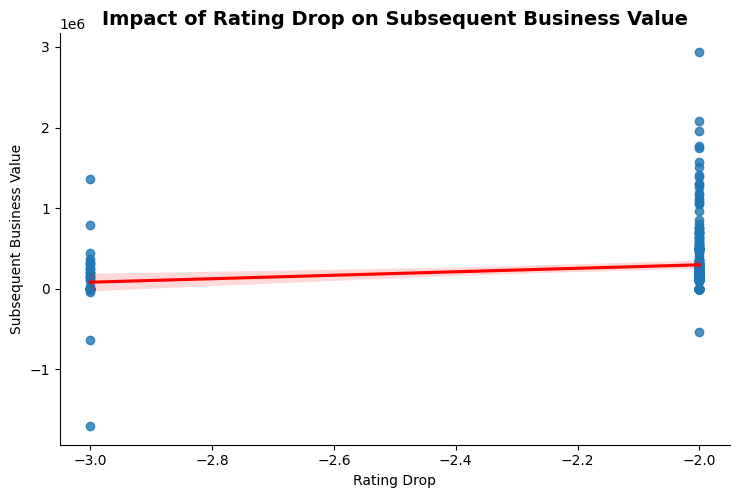

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    data=regression_data,
    x='Rating_Drop',
    y='Subsequent_Business_Value',
    height=5, aspect=1.5,
    line_kws={'color':'red'}
)
plt.title("Impact of Rating Drop on Subsequent Business Value", fontsize=14, fontweight='bold')
plt.xlabel("Rating Drop")
plt.ylabel("Subsequent Business Value")
plt.show()

#Observations:
- **Most rating drops are concentrated at -2 and -3, so major drops in this dataset mostly happen at these two levels.**
- **Business values are widely spread at both rating-drop levels, meaning drivers with the same rating drop can still generate very different next-month business values.**
- **The red regression line is slightly upward, which suggests a very weak positive relationship between rating drop and next month’s business value.**
- **There is high variability and several outliers, with a few drivers showing unusually high or unusually low business values after the rating drop.**
- **The plot does not show a strong clear pattern, so rating drop alone may not strongly**


---
###**Identifying Features Impacting Quarterly Rating**
---
- **We want to find which numeric features significantly influence a driver’s Quarterly Rating.**
- **Uses OLS regression and p-values to determine statistical significance.**
- **Helps prioritize features for driver performance analysis and predictive modeling.**
---

---
###**WHAT IS THE PURPOSE**
---
>**Which numerical variables are statistically related to Quarterly Rating?**
- **So Here:**
  - **Target (y) = Quarterly Rating**
  - **Features (X) = other numerical columns**
- **The goal is to identify which numeric variables have meaningful association with rating**
---
###**WHAT HAPPENS STEP BY STEP**
---
>**Create a copy**
---

In [100]:
df5 = df4.copy()

**KEEP ONLY NUMERICAL COLUMNS**

In [101]:
numerical_df = df5.select_dtypes(include=['int64', 'float64'])

- **This removes categorical columns like city codes**

**DROP NON-RELEVANT COLUMNS**

In [102]:
exclude_columns = ['Reporting_Date', 'Dateofjoining', 'LastWorkingDate']
numerical_df = numerical_df.drop(columns=exclude_columns, errors='ignore')

- **Date variables are not useful in this numeric OLS setup.**

**REMOVE MISSING VALUES**

In [103]:
numerical_df.dropna(inplace=True)

- **OLS cannot handle missing values.**

**SEPARATE PREDICTORS AND TARGET**

In [104]:
X = numerical_df.drop('Quarterly Rating', axis=1)
y = numerical_df['Quarterly Rating']

>**Here:**
- **x = Input variables**
- **y = rating to be explained**

**ADD INTERCEPT**

In [105]:
X = sm.add_constant(X)

- **This adds the constant term:**
  - **y = beta + beta1x1 + beta2x2 +...**
  

**FIT MODEL**

In [106]:
model = sm.OLS(y, X).fit()

- **Now OLS Estimates**
  - **Which numerical variables explain changes in Quarterly Rating?**

**PRINT SUMMARY**

In [107]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Quarterly Rating   R-squared:                       0.410
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     1002.
Date:                Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                        03:41:53   Log-Likelihood:                -16709.
No. Observations:               14441   AIC:                         3.344e+04
Df Residuals:                   14430   BIC:                         3.352e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

**EXTRACT SIGNIFICANT FEATURES**

In [108]:
p_values = model.pvalues
significant_features = p_values[p_values < 0.05].index.tolist()

- **This keeps only variables with p-value < 0.05.**
- **Meaning:**
  - **statistically significant relationship with quarterly rating.**

**visually inspect how each significant numerical feature relates to Quarterly Rating.**

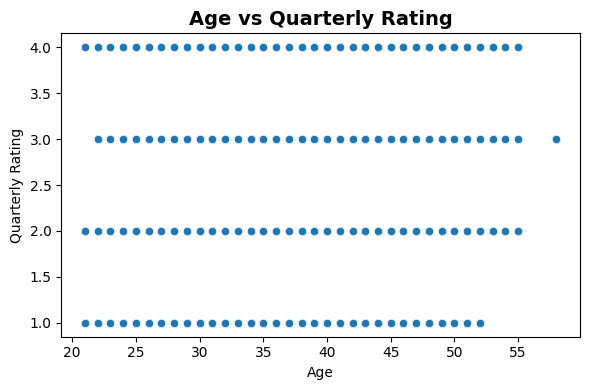

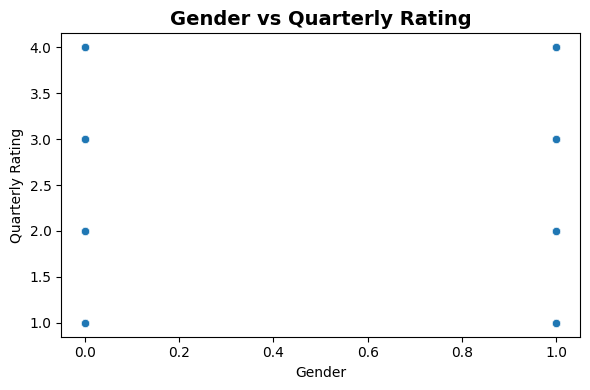

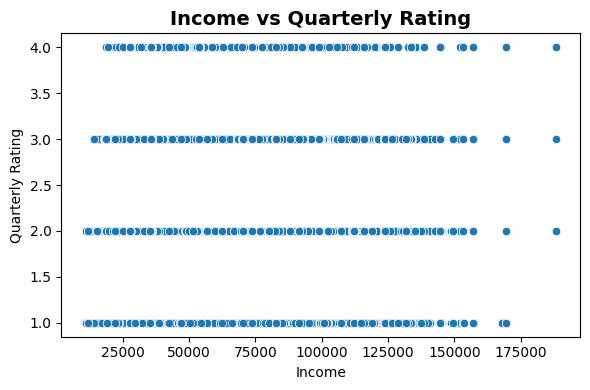

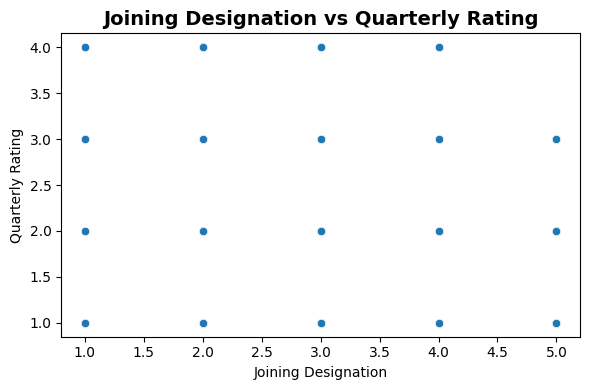

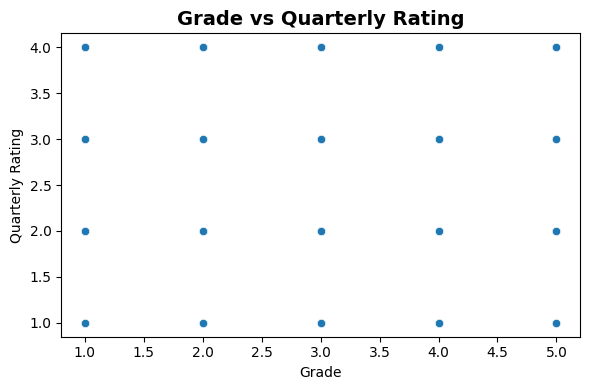

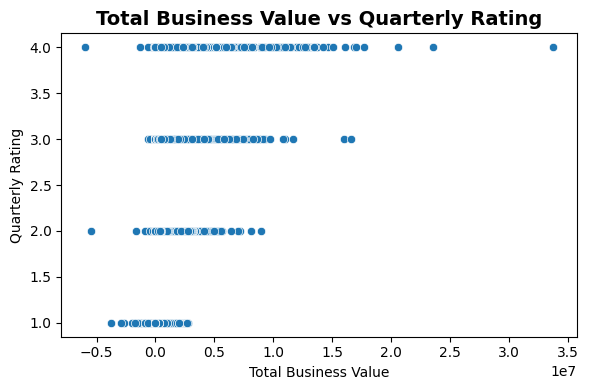

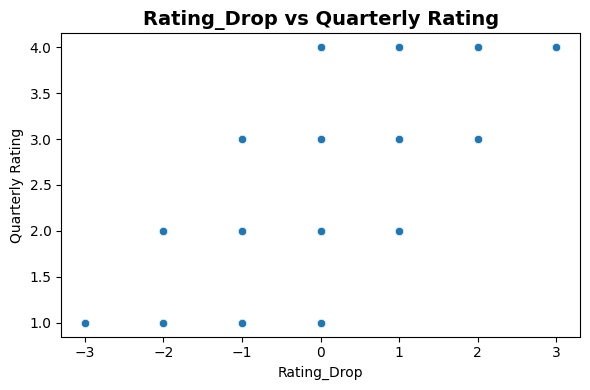

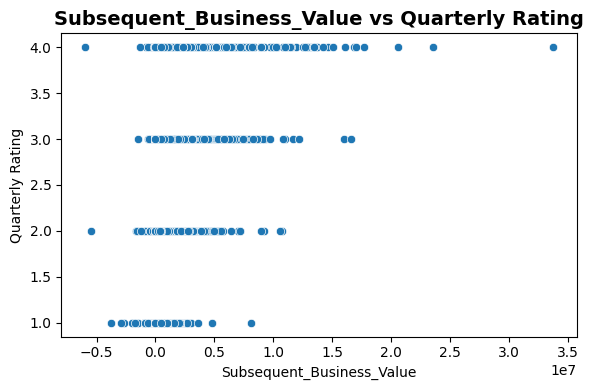

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in significant_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df5, x=feature, y='Quarterly Rating')
    plt.title(f'{feature} vs Quarterly Rating', fontsize=14, fontweight='bold')
    plt.xlabel(feature)
    plt.ylabel('Quarterly Rating')
    plt.tight_layout()
    plt.show()

---
###**WHATHER EACH CATEGORICAL FEATURE IS RELATED TO CHURN OR NOT**
---
>**Is this feature associated with driver churn?**
- **feature → Gender, City, Grade, Quarterly Rating, etc.**
- **target → Target (0 = stayed, 1 = left)**
- **It is a feature–target dependency test.**
---
###**WHAT IS THE NULL HYPOTHESIS**
---
- **H₀ (null hypothesis)**
  - **Feature and churn are independent**
- **Meaning: feature does not affect churn**
- **H₁ (alternative hypothesis)**
  - **Feature and churn are associated**
- **Meaning: churn differs across feature categories**
---

---
###**Hypothesis Testing: Identifying Independent Categorical Features**
---

In [111]:
from scipy.stats import chi2_contingency
import pandas as pd

# List of categorical features to test
newcat2_cols = ['Reportings','Gender','City','Education_Level','Grade',
                'Joining Designation','Quarterly Rating','Rating_incr','Income_incr']

# Loop over features and perform Chi-Square Test
print("Hypothesis Testing Results (p-value > 0.05 indicates independent feature):\n")
for col in newcat2_cols:
    # Create contingency table
    contingency_table = pd.crosstab(df3[col], df3['Target'])

    # Perform Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Print independent (not significant) features
    if p > 0.05:
        print(f"Independent feature (Not Significant): {col} | p-value = {p:.4f}")


Hypothesis Testing Results (p-value > 0.05 indicates independent feature):

Independent feature (Not Significant): Gender | p-value = 0.6944
Independent feature (Not Significant): Education_Level | p-value = 0.4664


#Observations:
- **Gender has p-value = 0.6944, which is greater than 0.05, so gender is independent of churn.**
- **Education Level has p-value = 0.4664, which is also greater than 0.05, so education level is independent of churn.**
- **This means driver leaving behavior does not change much across gender or education groups.**
- **Gender and education are not strong predictors of attrition in this dataset.**
- **Other variables like quarterly rating, rating growth, income growth, grade, and designation are likely more useful for churn analysis.**


In [112]:
significant_features = [col for col in newcat2_cols
                        if chi2_contingency(pd.crosstab(df3[col], df3['Target']))[1] <= 0.05]

print("\n Significant features impacting Target:")
for feature in significant_features:
    print(f"- {feature}")


 Significant features impacting Target:
- Reportings
- City
- Grade
- Joining Designation
- Quarterly Rating
- Rating_incr
- Income_incr


#Observations:
- **Reportings, City, Grade, Joining Designation, Quarterly Rating, Rating increase, and Income increase are significantly related to churn.**
- **This means driver attrition changes across different categories of these variables.**
- **Performance-related features such as Quarterly Rating, Rating increase, and Income increase show strong association with churn, indicating growth and performance matter for retention.**
- **Career-level features like Grade and Joining Designation also influence whether drivers stay or leave.**
- **City is significant, which suggests local market conditions and city-level operational differences may affect driver churn.**


---
###**Data Preparation for Modeling: Encoding, Scaling, and Train-Test Split**
---
- **Before modeling, the dataset needs to be cleaned and transformed.**
- **Steps include:**
  - **Removing irrelevant columns (e.g., IDs, dates).**
  - **Feature engineering (extracting Month/Year from Date of Joining).**
  - **Encoding categorical variables for ML models.**
  - **Scaling numerical features for models sensitive to magnitude.**
  - **Train-test split to evaluate model performance.**
  - **Handling class imbalance using SMOTE for churn prediction.**
---

---
###**PURPOSE : IT CONVERTS THE CLEANED DRIVER-LEVEL DATA INTO FORMAT THAT ALGORITHMS CAN USE**
---


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

**REMOVE UNNECESSARY COLUMNS**

In [ ]:
df_prep = df2.drop(columns=['Driver_ID','LastWorkingDate'], axis=1)

>**These are removed because:**
- **Driver_ID → only an identifier, not useful for prediction**
- **LastWorkingDate → used to create Target, so keeping it may cause data leakage**


**EXTRACT MONTH AND YEAR FROM JOINING DATE**

In [ ]:
df_prep['Month'] = df_prep['Dateofjoining'].dt.month
df_prep['Year'] = df_prep['Dateofjoining'].dt.year

>**This creates new useful features:**
- **Month → joining month**
- **Year → joining year**
- **These may capture hiring-period effects.**


**DROP ORIGINAL DATE COLUMNS**

In [ ]:
df_prep.drop('Dateofjoining', axis=1, inplace=True)

- **After extracting month and year, full date is no longer needed.**

**ONE-HOT ENCODE CITY**

In [ ]:
df_encoded = pd.get_dummies(df_prep, columns=['City'], drop_first=True) * 1

- **Machine learning models cannot directly use text labels like C1, C2.**
- **So this creates binary columns.**

**WHAT OUTPUT WILL YOU GET**

In [ ]:
df_encoded.head(10)

>**You will see the first 10 rows of the transformed dataset**
- **numerical features**
- **engineered month/year**
- **binary city columns**
- **target variable**


---
###**Train-Test Split and Feature Scaling**
---
- **Before modeling, we need to:**
  - **Split the dataset into training and testing sets to evaluate model performance.**
  - **Scale features so that all numerical variables are in the same range (important for algorithms like Logistic Regression, KNN, SVM).**
---

**SEPARATE FEATURES AND TARGET**

In [114]:
from sklearn.model_selection import train_test_split

# Separate independent (X) and dependent (y) datasets
X = df_encoded.drop('Target', axis=1)
y = df_encoded['Target']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Display shapes and target distribution
print("Train-Test Split Completed")
print("-" * 50)
print("X_train shape:", X_train.shape)
print("-" * 50)
print("X_test shape:", X_test.shape)
print("-" * 50)
print("y_train distribution:\n", y_train.value_counts())
print("-" * 50)
print("y_test distribution:\n", y_test.value_counts())
print("-" * 50)

Train-Test Split Completed
--------------------------------------------------
X_train shape: (1904, 41)
--------------------------------------------------
X_test shape: (477, 41)
--------------------------------------------------
y_train distribution:
 Target
1    1292
0     612
Name: count, dtype: int64
--------------------------------------------------
y_test distribution:
 Target
1    324
0    153
Name: count, dtype: int64
--------------------------------------------------


- **Your train-test split is clean, balanced in proportion, and ready for model building. The main thing to watch is class imbalance in the target variable.**

---
###**Feature Scaling (Min-Max Scaling)**
---

In [115]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Initialize scaler
scaler = MinMaxScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Display first 5 rows of scaled training set
X_train_scaled.head()

,Reportings,Age,Gender,Education_Level,Grade,Total Business Value,Income,Joining Designation,Quarterly Rating,Rating_incr,...,City_C27,City_C28,City_C29,City_C3,City_C4,City_C5,City_C6,City_C7,City_C8,City_C9
0,0.043478,0.351351,1.0,0.0,0.50,0.014326,0.525190,0.50,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.000000,0.567568,0.0,0.0,0.00,0.014326,0.229818,0.00,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.086957,0.162162,0.0,0.5,0.25,0.014326,0.364218,0.25,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.378378,0.0,0.5,0.50,0.314589,0.332125,0.00,0.666667,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.405405,0.0,0.0,0.50,0.014326,0.554671,0.25,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---
###**Checking Class Imbalance in Target Variable**
---


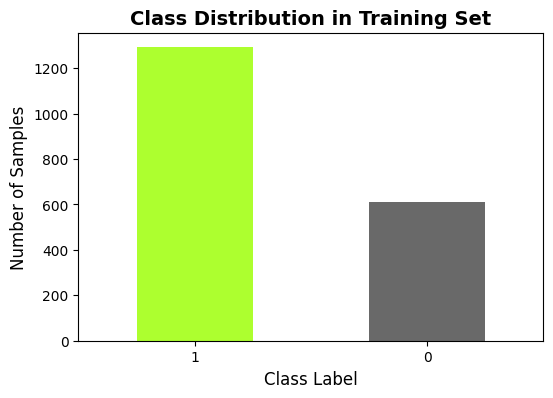

Class Ratio (Majority / Minority): 2.11


In [116]:
import matplotlib.pyplot as plt

# Count class frequencies in training set
class_counts = y_train.value_counts()

# Plot class distribution
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['greenyellow', 'dimgrey'])
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.show()

# Print class ratio
majority_class = class_counts.iloc[0]
minority_class = class_counts.iloc[1]
print(f"Class Ratio (Majority / Minority): {majority_class / minority_class:.2f}")

#Observations:
- **Class 1 has more samples than Class 0.
Training data has about 1292 Class 1 and 612 Class 0.**
- **The training data is imbalanced.
Class 1 is about twice the size of Class 0.**
- **The model may learn Class 1 better.
Because Class 1 appears more often, the model may predict it more frequently.**
- **Accuracy alone may not be enough.
It is better to also check precision, recall, and F1-score.**
- **Balancing methods may help.
Techniques like SMOTE, undersampling, or class weights can improve performance**



---
###**Handling Class Imbalance using SMOTE (Synthetic Minority Oversampling Technique)**
---
- **In imbalanced datasets, models often predict the majority class and ignore the minority class.**
- **SMOTE generates synthetic samples of the minority class to balance the dataset.**
- **This improves model performance for metrics like F1-score, ROC-AUC, and Recall.**
---


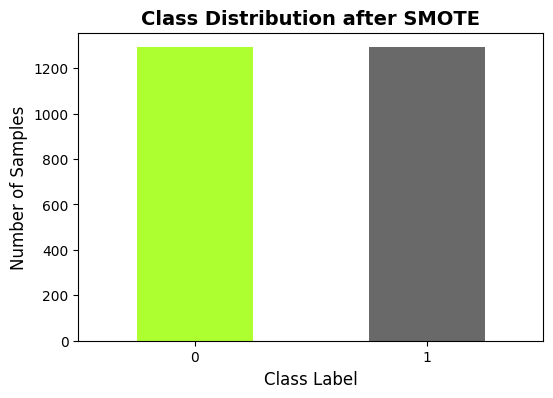

Class Ratio (Majority / Minority) after SMOTE: 1.00


In [117]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to training data
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Check new class distribution
class_counts = y_train_res.value_counts()

# Plot class distribution after SMOTE
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar', color=['greenyellow', 'dimgrey'])
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution after SMOTE', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.show()

# Print class ratio
majority_class = class_counts.iloc[0]
minority_class = class_counts.iloc[1]
print(f"Class Ratio (Majority / Minority) after SMOTE: {majority_class / minority_class:.2f}")

#Observations:
- **Both classes are now balanced.
After SMOTE, Class 0 and Class 1 have almost equal samples (about 1292 each).**
- **SMOTE increased the minority class.
It created new samples for Class 0 until it matched Class 1.**
- **The model can learn both classes better.
Earlier the model saw more Class 1. Now both classes get equal importance.**
- **Prediction for minority class may improve.
Metrics like recall and F1-score for Class 0 can improve.**
- **Synthetic data should be used carefully.
If artificial points are created near noisy areas, the model may slightly overfit.**


---
##**Ensemble Learning: Random Forest Classifier with Hyperparameter Tuning**
---
>**Explanation:**
- **Random Forest is an ensemble method using Bagging, which combines multiple decision trees to improve predictive performance.**
- **GridSearchCV is used to find the best hyperparameters for the model using cross-validation.**
- **Evaluation includes accuracy, confusion matrix, feature importance, ROC-AUC, and precision-recall curves.**
---


---
###**PURPOSE**
---
>**You already:**
- **Cleaned the data**
- **Split train or test**
- **balanced training data using SMOTE**
- **Now the question becomes:**
  - **Which Random Forest settings give the best churn prediction?**
- **That is what GridSearchCV does.**
---


**Hyperparameter Tuning using GridSearchCV**

In [118]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time


params = {"max_depth":[7,10,15],
             "n_estimators":[100,200,300,400],
             "max_features":[4,7,10],
             "ccp_alpha":[0.0005,0.00075,0.001]}


grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=params, cv=5, n_jobs=-1, verbose=2)

# Measure the time taken to fit the model
start_time = time.time()
grid_search.fit(X_train_res, y_train_res)
end_time = time.time()

print("Best parameters found by GridSearchCV:", grid_search.best_params_)
print(f"Total training time: {end_time - start_time:.2f} seconds")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found by GridSearchCV: {'ccp_alpha': 0.0005, 'max_depth': 15, 'max_features': 10, 'n_estimators': 100}
Total training time: 745.13 seconds


#Observations:
- **Many models were tested.
A total of 540 models were trained.**
- **Best settings were found.
The best model used depth 15, 100 trees, and 10 features per split.**
- **The model needs some complexity.
Deeper trees helped capture churn patterns better.**
- **More trees were not necessary.
100 trees worked better than larger forests.**
- **Training took time.
It took about 12 minutes to finish.**


---
###**Model Evaluation: Accuracy**
---

In [119]:
from sklearn.metrics import accuracy_score

# Retrieve the best model
best_model = grid_search.best_estimator_

# Predictions
y_train_pred = best_model.predict(X_train_res)
y_test_pred = best_model.predict(X_test_scaled)

# Accuracy scores
train_accuracy = accuracy_score(y_train_res, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Training Accuracy: 0.98
Test Accuracy: 0.89


#Observations:
- **The model learned the training data very well.
Training accuracy is 98%.**
- **The model also performs well on unseen data.
Test accuracy is 89%**
- **Test accuracy is lower than training accuracy.
This means the model fits training data better than new data.**
- **There may be slight overfitting.
The gap between 98% and 89% suggests some overfitting, but test performance is still strong.**
- **Overall, the model is performing well.
It captures churn patterns reasonably well on unseen drivers.**


---
###**CONFUSION MATRIX - RANDOM FOREST**
---
>**This code shows how the model’s predictions compare with the actual churn values.**
- **Accuracy gives only one number.**
- **A confusion matrix shows where the model is correct and where it makes mistakes.**
---

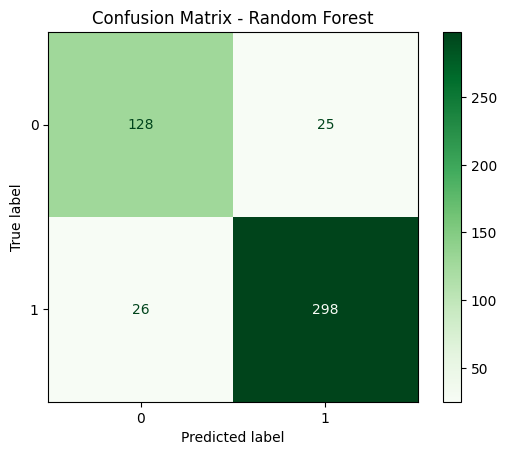

In [120]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix for test set
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.show()

#Observations:
- **The model predicts most cases correctly.
It correctly identified 298 churned drivers and 128 retained drivers.**
- **Only a small number of mistakes were made.**
  - **25 retained drivers were predicted as churn**
  - **26 churned drivers were predicted as retained**
- **Overall accuracy is good.
The model achieved about 89% accuracy.**
- **The model identifies churn well.
It correctly detected about 92% of churn cases.**
- **Performance is slightly better for churn than retained drivers.
The model predicts Class 1 (churn) a little better than Class 0 (retained).**


---
###**Feature Importance**
---

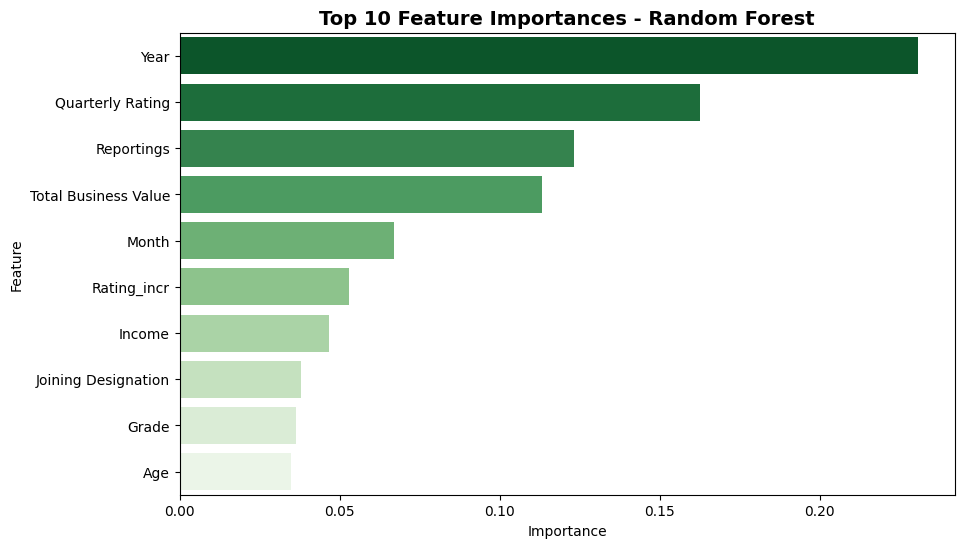

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances
importances = best_model.feature_importances_
feature_names = X_train_res.columns

# Create DataFrame for plotting
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot top 10 important features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='Greens_r')
plt.title('Top 10 Feature Importances - Random Forest', fontsize=14, fontweight='bold')
plt.show()

#Observations:
- **Year is the most important feature.
This means the model found strong time-related patterns in churn.**
- **Quarterly Rating is also a strong predictor.
Driver performance has a major effect on churn prediction.**
- **Reportings and Total Business Value are important.
Work activity and business contribution influence the model.**
- **Month and Rating increase have moderate impact.
Timing and recent improvement also matter.**
- **Age, Grade, Income, and Joining Designation are less important.
Performance-related features are more useful than demographic features**


---
###**ROC Curve and AUC**
---

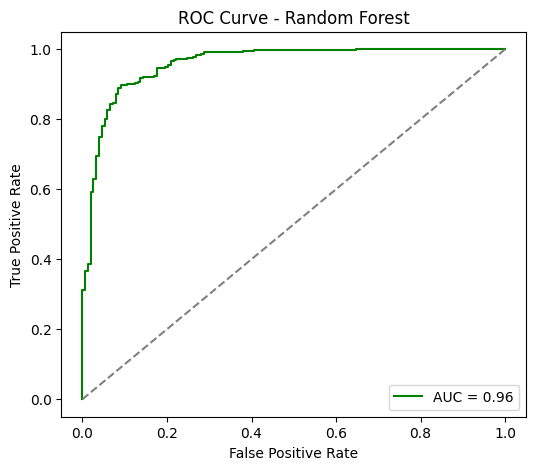

In [122]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities
y_test_prob = best_model.predict_proba(X_test_scaled)[:,1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc_score = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='green', label=f'AUC = {auc_score:.2f}')
plt.plot([0,1], [0,1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

#Observations:
- **The model separates the two classes very well.**
  - **An AUC of 0.96 means the model can correctly rank a churned driver higher than a retained driver about 96% of the time.**
- **The curve stays close to the top-left corner.**
  - **This is a strong sign because it means the model gets high true positives while keeping false positives low.**
- **It performs much better than random guessing.**
  - **The diagonal line represents random prediction (AUC = 0.50). Your curve is far above that line**
- **The model is reliable across different thresholds.**
  - **Even if you change the cutoff probability, the model still keeps good separation between churn and non-churn.**
- **Business meaning**
  - **The model is good at identifying drivers likely to churn.**
  - **This is useful for early retention actions, such as focusing on low-rated drivers, no rating increase, or no income increase.**


---
###**Precision-Recall Curve**
---

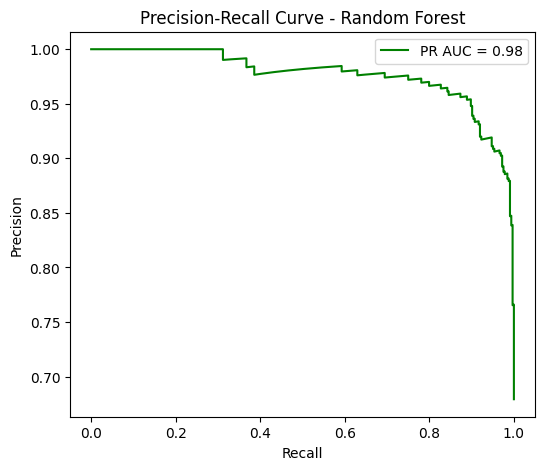

In [123]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green', label=f'PR AUC = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend()
plt.show()

#Observations:
- **PR AUC = 0.98 is excellent.
The model is very strong at identifying churn correctly.**
- **The curve stays near the top-right corner.
This means the model keeps both high precision and high recall.**
- **Even when recall increases, precision remains high.
So the model finds most churn cases without making many false alarms.**
- **The sharp drop near the end is normal.
To capture almost every churn case, the model starts making more wrong positive predictions.**
- **What this means**
  - **When the model predicts a driver will churn, it is usually correct.**
  - **At the same time, it also finds most of the actual churners.**
- **Why PR curve matters here**
  - **Your dataset originally had class imbalance. In that situation, PR curve is often more useful than ROC curve because it focuses directly on how well the model detects the positive class (churn).**
- **Final takeaway**
- **Your modeling pipeline looks strong:**
  - **Before SMOTE: class imbalance**
  - **After SMOTE: balanced training data**
  - **Random Forest: learned useful patterns**
  - **ROC AUC = 0.96 → strong class separation**
  - **PR AUC = 0.98 → strong churn detection**
- **Overall: the model is good for identifying drivers who are likely to churn, which makes it useful for retention planning.**


---
###**WHY LIGHTGBM**
---
>**LightGBM is a boosting algorithm.**
- **It builds trees one after another.**
- **Each new tree tries to correct mistakes made by previous trees.**
- **That is why it often performs better than a single tree.**
---

---
##**Ensemble Learning – Boosting (LightGBM)**
---
##**Hyperparameter Tuning (GridSearchCV)**
---

In [124]:
import lightgbm as lgb

In [125]:
import sys
import os

In [126]:
class DummyFile(object):
    def write(self, x):
        pass

# Redirect stderr to dummy file
sys.stderr = DummyFile()

# Suppress LightGBM and other warnings
os.environ['PYTHONWARNINGS'] = 'ignore'

# Reset stderr
sys.stderr = sys.__stderr__

# Reset PYTHONWARNINGS
del os.environ['PYTHONWARNINGS']

# Configure LightGBM to suppress warnings
model = lgb.LGBMClassifier(silent=True, verbose=-1)


# Define the grid of parameters to search
gridParams = {
    'learning_rate': [0.1, 0.3, 0.5],
    'boosting_type': ['gbdt'],
    'objective': ['binary'],
    'max_depth': [5, 6, 7, 8],
    'colsample_bytree': [0.5, 0.7],
    'subsample': [0.5, 0.7]
      }
# Setup GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=gridParams, cv=3, scoring='neg_log_loss',verbose=2)

start_time=time.time()
grid.fit(X_train_res, y_train_res)
end_time=time.time()

# Print the best parameters found
print("Best parameters found: ", grid.best_params_)
# Best score
print("Best log loss: ", -grid.best_score_)
print(f"Total training time: {end_time - start_time:.2f} seconds")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END boosting_type=gbdt, colsample_bytree=0.5, learning_rate=0.1, max_depth=5, objective=binary, subsample=0.5; total time=   0.2s
[CV] END boosting_type=gbdt, colsample_bytree=0.5, learning_rate=0.1, max_depth=5, objective=binary, subsample=0.5; total time=   0.1s
[CV] END boosting_type=gbdt, colsample_bytree=0.5, learning_rate=0.1, max_depth=5, objective=binary, subsample=0.5; total time=   0.1s
[CV] END boosting_type=gbdt, colsample_bytree=0.5, learning_rate=0.1, max_depth=5, objective=binary, subsample=0.7; total time=   0.1s
[CV] END boosting_type=gbdt, colsample_bytree=0.5, learning_rate=0.1, max_depth=5, objective=binary, subsample=0.7; total time=   0.1s
[CV] END boosting_type=gbdt, colsample_bytree=0.5, learning_rate=0.1, max_depth=5, objective=binary, subsample=0.7; total time=   0.1s
[CV] END boosting_type=gbdt, colsample_bytree=0.5, learning_rate=0.1, max_depth=6, objective=binary, subsample=0.5; total time= 

#Observations:
- **Grid search tested 48 parameter combinations using 3-fold cross-validation, so the model was trained 144 times.**
- **Best parameters found:**
  - **learning_rate = 0.1**
  - **max_depth = 5**
  - **colsample_bytree = 0.7**
  - **subsample = 0.5**
- **Best log loss = 0.2521**
  - **Lower log loss means the predicted probabilities are closer to the true class labels, so this is a good result.**
- **Training time was only 25.79 seconds.**
  - **This is much faster than Random Forest (which took about 745 seconds).**
- **LightGBM found a good model quickly.**
- **It preferred smaller, simpler trees with controlled randomness.**
- **Compared with your Random Forest, LightGBM is much more computationally efficient while still giving strong predictive performance.**


In [127]:
# Retrieve the best model (estimator)
best_model = grid.best_estimator_

# Make predictions on the test set
y_train_pred = best_model.predict(X_train_res)
y_test_pred = best_model.predict(X_test_scaled)

# Evaluate the model
# Accuracy
train_accuracy = accuracy_score(y_train_res, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2f}")

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.2f}")

Training Accuracy: 0.96
Test Accuracy: 0.92


#Observations:
- **Training accuracy = 96%
The model learned the patterns in the training data very well.**
- **Test accuracy = 92%
The model also performs strongly on unseen data.**
- **Difference between train and test = 4%
This is a small gap, which suggests good generalization. The model is not heavily overfitting.**
- **Compared with your earlier Random Forest (98% train, 89% test), LightGBM gives better test performance and a smaller train–test gap.**
- **The model is accurate and stable.**
- **It performs well on both training and testing data.**
- **LightGBM appears more reliable for this churn classification problem.**


---
###**Confusion Matrix**
---

In [128]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[133  20]
 [ 17 307]]


#Observations:
- **133 drivers were correctly predicted as non-churners (Class 0).**
- **307 drivers were correctly predicted as churners (Class 1).**
- **20 drivers were predicted as churners but were actually non-churners.**
- **17 drivers were predicted as non-churners but actually churned.**
- **The model is making more correct predictions than mistakes.**
- **Total errors are 37 out of 477 test cases, which is relatively low.**
- **The errors are also fairly balanced (20 vs 17), meaning the model is not strongly biased toward one class.**


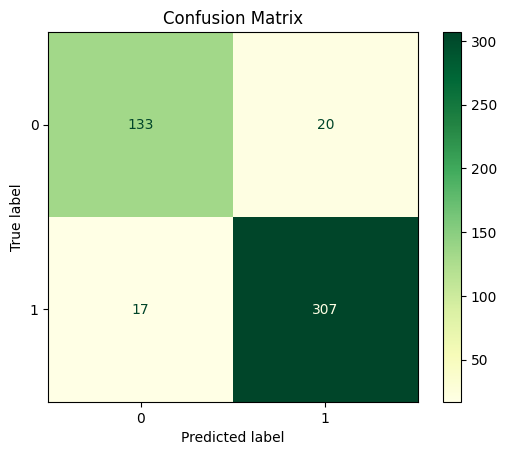

In [129]:
disp = ConfusionMatrixDisplay(conf_matrix)
cmap = plt.cm.YlGn
disp.plot(cmap=cmap)
plt.title('Confusion Matrix')
plt.show()

#Observations:
- **307 churn drivers were predicted correctly.**
- **133 non-churn drivers were predicted correctly.**
- **Only 37 predictions were wrong.**
- **Compared with previous model**
  - **Previous model made 51 mistakes.**
  - **This model made 37 mistakes.**
- **What it means**
  - **This model is better than the previous one.**
  - **It finds churn drivers more accurately.**
  - **Test accuracy is about 92%.**

In [130]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       153
           1       0.94      0.95      0.94       324

    accuracy                           0.92       477
   macro avg       0.91      0.91      0.91       477
weighted avg       0.92      0.92      0.92       477



#Observations:
- **The model performs better for churn drivers (Class 1) than non-churn drivers.**
- **It is very good at identifying drivers who are likely to leave.**
- **Macro average and weighted average are both around 91–92%, which shows balanced overall performance.**


---
###**Improved & Cleaner Visualization**
---

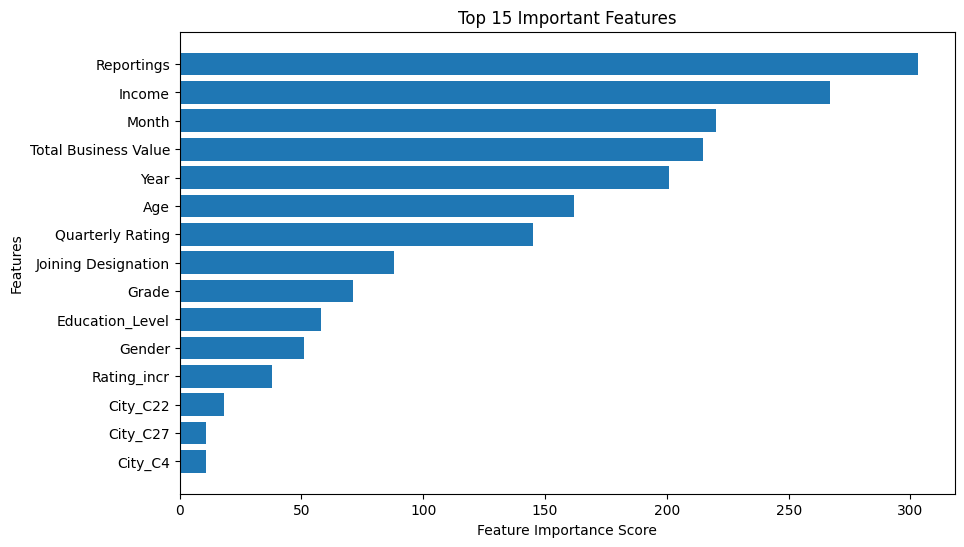

In [131]:
# Convert to DataFrame
fi_df = pd.DataFrame({
    'Feature': X_train_res.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'][:15], fi_df['Importance'][:15])
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Top 15 Important Features')
plt.gca().invert_yaxis()
plt.show()

#Observations:
- **Reportings is the most important feature in the model.**
- **Income is the second most important feature.**
- **Month, Total Business Value, and Year also strongly affect churn prediction.**
- **Quarterly Rating has good importance, but it is lower than business-related variables.**
- **Joining Designation, Grade, Age, Education Level, and Gender have smaller impact.**
- **City variables such as C22, C27, and C4 have the least importance.**
- **The model mainly depends on work performance, income, and time-related factors.**
- **Personal or demographic features matter less compared with operational and performance-related features.**

---
###**Model Evaluation: ROC Curve & AUC Analysis (LightGBM)**
---

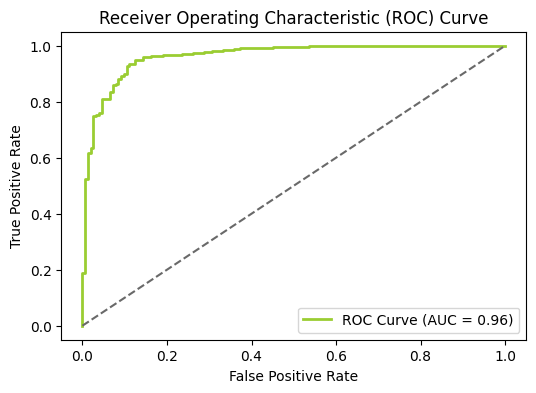

ROC-AUC Score: 0.964


In [132]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for the positive class
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Compute AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(
    fpr, tpr,
    color='yellowgreen',
    lw=2,
    label='ROC Curve (AUC = %0.2f)' % roc_auc
)

# Random classifier reference line
plt.plot([0, 1], [0, 1], color='dimgrey', linestyle='--')

# Axis labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')

plt.show()

# Print AUC score
print(f"ROC-AUC Score: {roc_auc:.3f}")

#Observations:
- **ROC-AUC = 0.96, which is an excellent score.**
- **The curve stays close to the top-left corner, which means the model separates churn and non-churn drivers very well.**
- **The green curve is far above the diagonal line, so the model performs much better than random guessing.**
- **The model has strong ability to distinguish between drivers who will churn and drivers who will stay.**
- **It can identify many true churn cases while keeping false alarms low.**


---
###**Precision–Recall Curve & PR-AUC (LightGBM)**
---

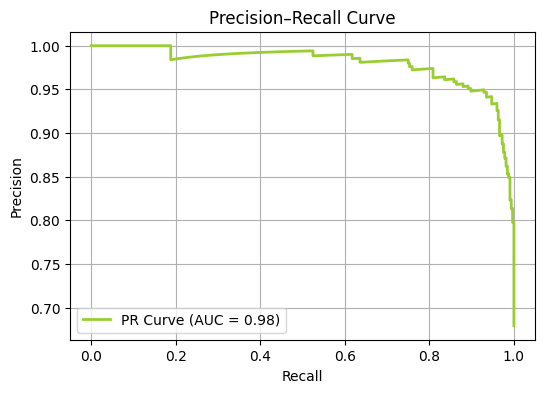

PR-AUC Score: 0.980


In [133]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the positive (churn) class
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Compute precision-recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Compute PR-AUC
pr_auc = auc(recall, precision)

# Plot Precision-Recall Curve
plt.figure(figsize=(6, 4))
plt.plot(
    recall,
    precision,
    color='yellowgreen',
    lw=2,
    label='PR Curve (AUC = %0.2f)' % pr_auc
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.grid(True)

plt.show()

# Print PR-AUC score
print(f"PR-AUC Score: {pr_auc:.3f}")

#Observations:
- **PR-AUC = 0.98, which is an excellent result.**
- **The curve stays very close to the top-right area, showing strong performance.**
- **Precision remains very high even when recall increases.**
- **There is a small drop near recall = 1, which means the model makes a few more mistakes when trying to capture almost all churn cases.**
- **The model is very good at finding churn drivers while keeping wrong churn predictions low.**
- **It performs especially well even though the original dataset had class imbalance.**


---
###**PROJECT OBJECTIVE**
---
>**The goal of this project was to understand why drivers leave the platform and identify the factors that most strongly predict churn.**
---

---
###**INSIGHTS**
---
###**1.HIGH OVERALL CHURN**
---
- **The dataset shows a high driver churn rate of about 68%.**
- **This means a large share of drivers are leaving the platform.**
---
###**2.HIRING SURGE FOLLOWED BY HIGH EXISTS**
---
- **Driver hiring increased sharply between 2018 and 2020.**
- **A large number of drivers also left during 2019 and 2020.**
- **Drivers who joined during rapid hiring periods showed higher churn.**
- **Insight: rapid expansion brought many junior drivers, but retention remained weak.**
---
###**3.LOW QUARTERLY RATINGS STRONGLY INCREASE CHURN**
---
- **Drivers with Quarterly Rating = 1 show the highest churn.**
- **Churn decreases as ratings improve.**
- **Drivers with Rating 3 or 4 are much more stable.**
- **Insight: quarterly rating acts as a strong signal of driver retention.**
---
###**4.RATING GROWTH MATTERS**
---
- **Drivers with no rating improvement had much higher churn.**
- **Drivers who showed rating increase were more likely to stay.**
- **Insight: not only current performance, but career progress affects retention.**
---
###**5.INCOME GROWTH REDUCES CHURN**
---
- **Most drivers did not receive income increases.**
- **Drivers with income growth had much lower churn.**
- **Insight: financial stagnation is one of the main churn drivers.**
---
###**6.EARLY-CAREER DRIVERS ARE MORE VULNERABLE**
---
- **Grade 1 and Joining Designation 1 drivers had the highest churn.**
- **Higher grades were relatively more stable.**
- **Insight: churn is concentrated among early-stage drivers.**
---
###**7.GEOGRAPHIC DIFFERENCES EXIST**
---
- **Some cities had high driver count but lower business value per driver.**
- **Some cities generated higher business value with better retention.**
- **Insight: driver volume alone does not guarantee efficiency.**
---
###**8.MOST IMPORTANT PREDICTORS FROM MODELING**
---
>**The machine learning models identified these important features:**
- **Reportings**
- **Income**
- **Month**
- **Total Business Value**
- **Year**
- **Quarterly Rating**
- **Insight: operational and performance variables are stronger predictors than demographic variables.**
---
###**MODELING SUMMARY**
---
- **Random Forest**
  - **Training accuracy: 98%**
  - **Test accuracy: 89%**
- **LightGBM**
   - **Training accuracy: 96%**
   - **Test accuracy: 92%**
- **Final model quality**
  - **ROC-AUC = 0.96**
  - **PR-AUC = 0.98**
- **Interpretation**
  - **The model can reliably identify drivers who are likely to churn.**
---
###**FINAL BUSINESS CONCLUSION**
---
- **The analysis shows that driver churn is mainly caused by career stagnation rather than demographic factors.**
- **The strongest churn pattern is: low rating + no rating growth + no income growth + early career stage**
- **That combination creates a high-risk churn group.**
---









---
###**RECOMMENDATIONS**
---
###**1.FOCUS ON EARLY-STAGE DRIVERS**
---
- **Monitor Grade 1 and newly joined drivers closely.**
- **Build early retention programs during the first few months.**
---
###**2.IMPROVE RATING PROGRESSION**
---
- **Create clear performance improvement paths.**
- **Offer training, coaching, and regular feedback.**
- **Goal: move drivers out of low-rating groups early.**
---
###**3.INTRODUCE INCENTIVE-BASED GROWTH**
---
- **Provide performance-linked incentives.**
- **Offer small but visible income growth opportunities.**
- **Reason: even moderate financial progress improves retention.**
---
###**4.BUILD CHURN RISK MONITORING**
---
- **Use model outputs to identify drivers with:**
  - **low ratings**
  - **no rating increase**
  - **low business value**
  - **early tenure**
- **These drivers should be flagged for intervention.**
---
###**5.FOCUS ON EFFICIENT CITIES**
---
- **Study cities with better retention and higher business value.**
- **Replicate their operational practices in weaker cities.**
---
###**ONE-LINE PROJECT TAKEAWAY**
---
- **Drivers leave mainly because they do not see growth in performance, income, or career progression.**
---